In [1]:
import torch
from hpc.models import SparseHopfieldNetwork, PatternAssociator, PATrainer
from hpc.hopfield_network_utils import *
from pcn.models import PCModel
from scipy.stats import kurtosis
from hpc.layers import SparseLayer
import pcn
from hpc import utils
from torch.utils.data import DataLoader, TensorDataset
from scipy import stats
from tqdm import tqdm
import pandas as pd
import seaborn as sns
from scipy.spatial import distance

# CA3 patterns

In [5]:
dataset = torch.load(f'data/mnist_patterns.pt')

C:\Users\lucfonta\AppData\Local\Temp\ipykernel_40008\2583382646.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  dataset = torch.load(f'data/mnist_patterns.pt')


In [18]:
N_patterns = 64
ca3 = dataset['ca3']

In [19]:
ca3.shape

torch.Size([64, 682])

Text(0.5, 0.98, 'These are 64 patterns our network will memorize')

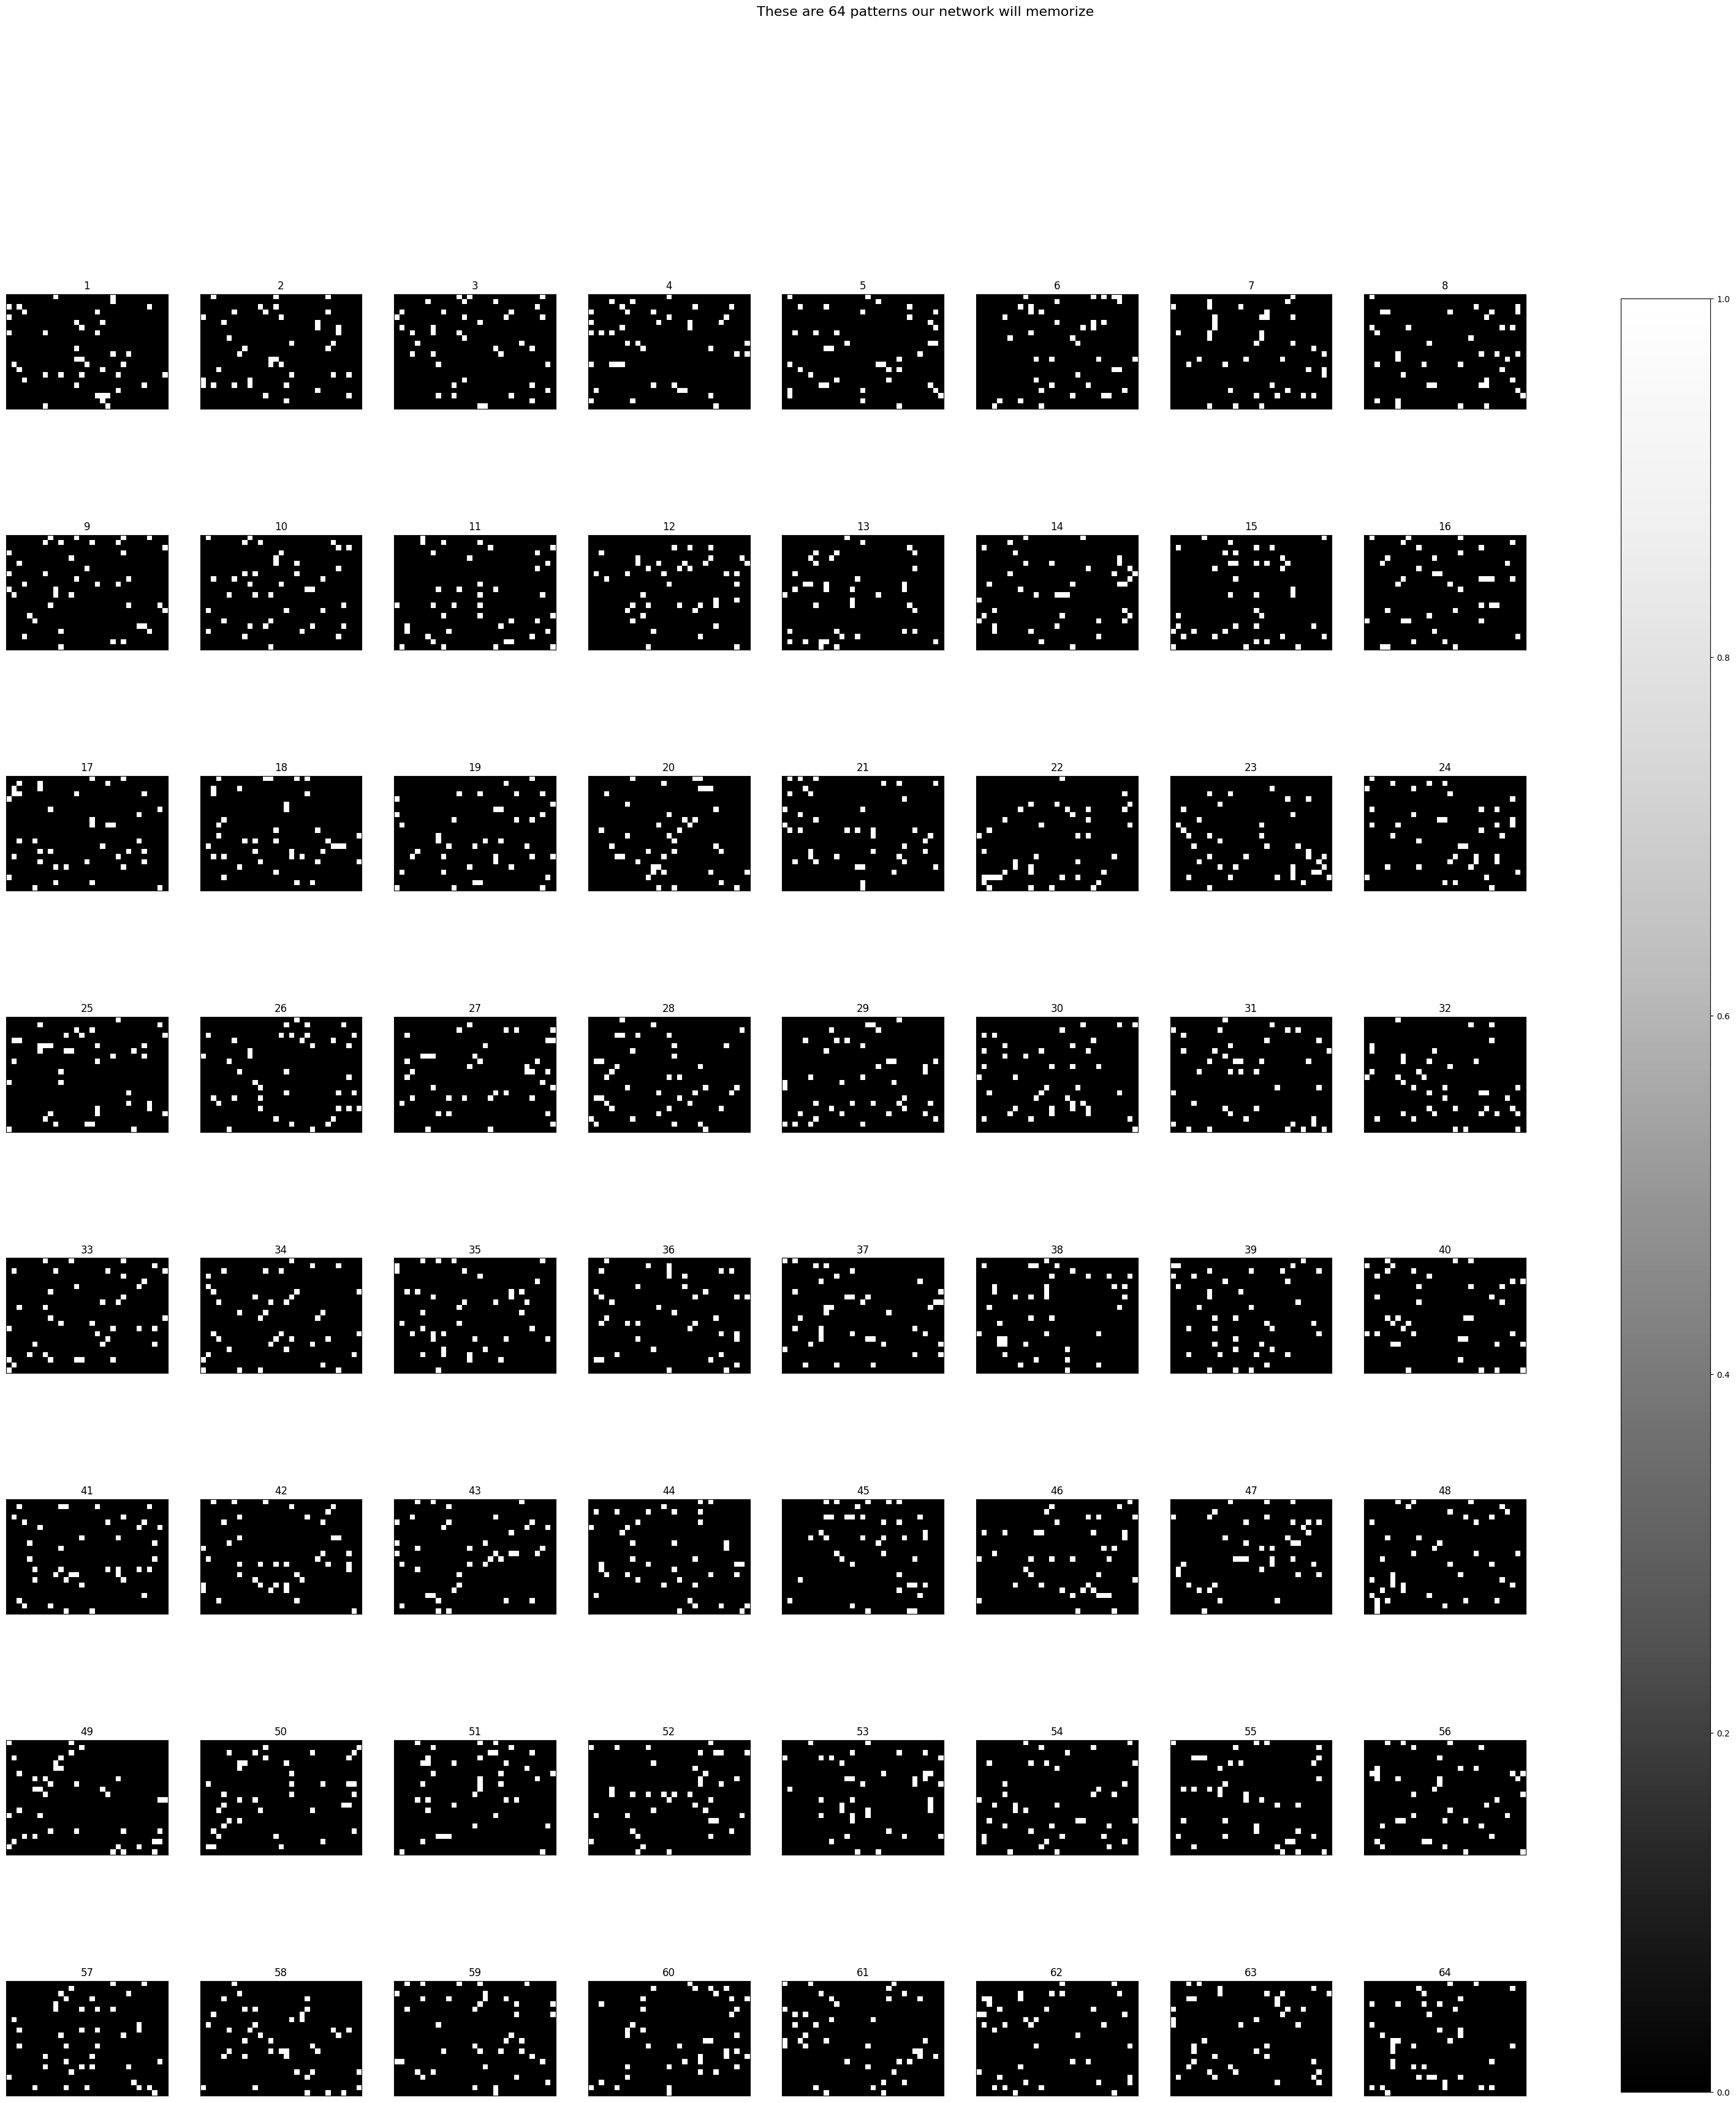

In [20]:
pattern_size = (22, 31)
ca3_patterns = {str(i) : ca3[i-1].reshape(pattern_size).numpy() for i in range(1,N_patterns+1)}
fig, ax = plot_patterns(ca3_patterns)
fig.suptitle(f"These are {ca3_patterns.__len__()} patterns our network will memorize", fontsize=16)

In [15]:
HFN = SparseHopfieldNetwork(ca3_patterns)

[0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0
 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 1 1 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1
 0 0 1 0 0 0 0 0 0 0 0 0 

(<Figure size 1600x400 with 2 Axes>,
 array([<Axes: title={'center': 'Network activity pattern'}>,
        <Axes: title={'center': 'Similarity to stored patterns'}>],
       dtype=object))

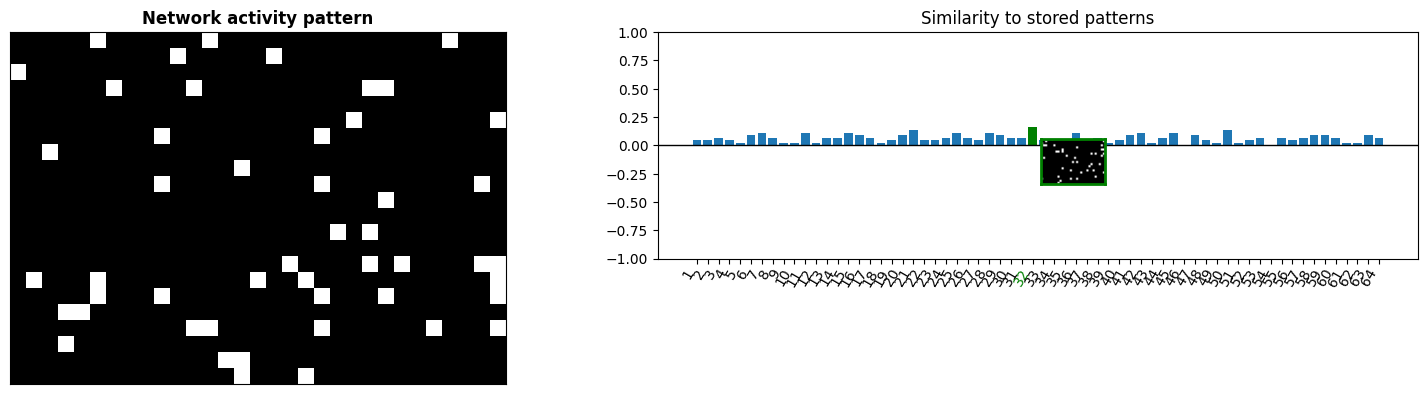

In [15]:
print(HFN.state)
HFN.visualise()

(<Figure size 1600x400 with 2 Axes>,
 array([<Axes: title={'center': 'State after 100 updates'}>,
        <Axes: title={'center': 'Similarity to stored patterns'}>],
       dtype=object))

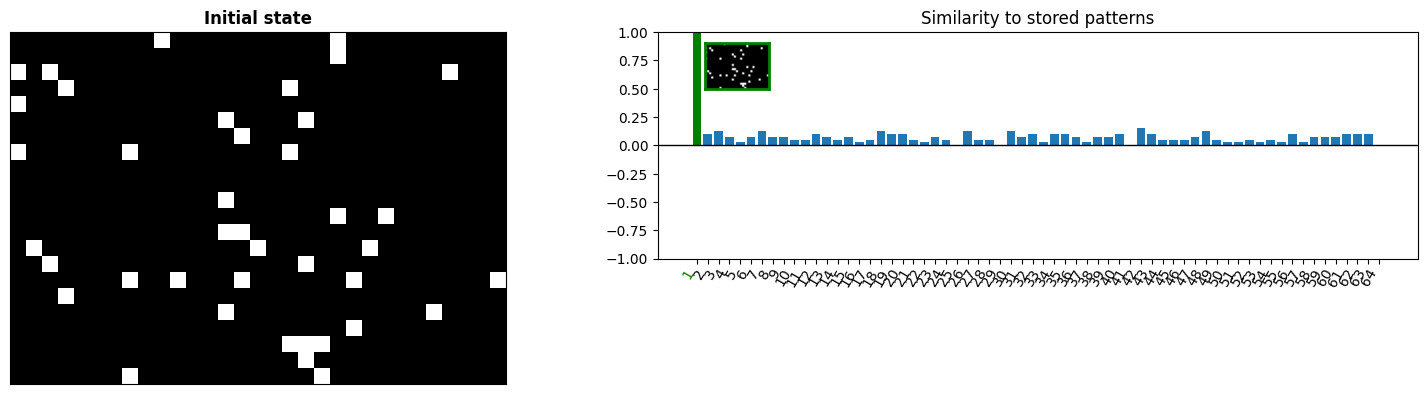

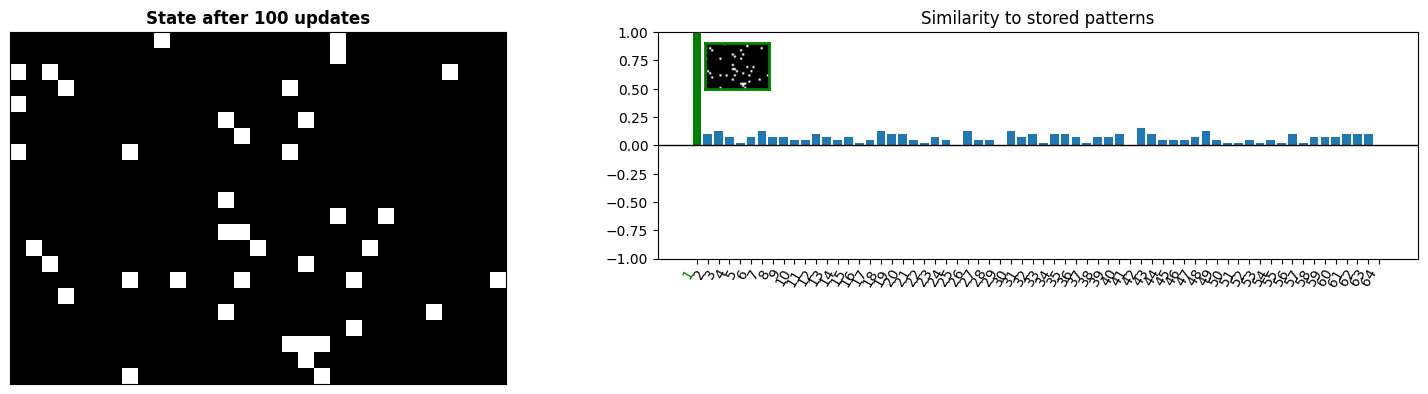

In [10]:
pattern_to_start = '1'

HFN.set_state(ca3_patterns[pattern_to_start].flatten()) #reinitialise the state of the network
HFN.visualise(title="Initial state")
for i in range(100):
    HFN.update_state(asynchronous=False)
HFN.visualise(title=f"State after {i+1} updates")

In [17]:
from scipy.spatial import distance
distance = distance.hamming(HFN.state, ca3_patterns[pattern_to_start].flatten())
print(distance)

0.0


n_steps: 100


C:\Users\lucfonta\.git\static-hpc\src\hpc\models.py:331: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(bottom=min(energy), top=max(energy))


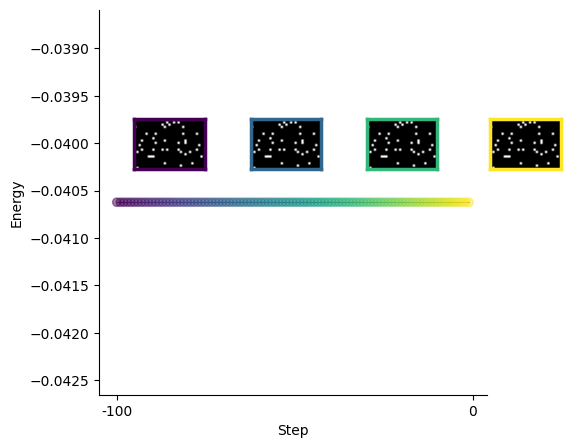

In [18]:
fig, ax = HFN.plot_energy(n_steps=100)

In [ ]:
pcn.utils.seed(0)
# test ALL the memories and set which ones are unstable
unstable_patterns = []
for pattern in ca3_patterns:
    HFN.set_state(ca3_patterns[pattern].flatten())
    initial_state = copy.deepcopy(HFN.state)
    for i in range(100):
        HFN.update_state(asynchronous=False)
    if not np.all(initial_state == HFN.state): #if a pattern is not stable, add it to the list
        unstable_patterns.append(pattern)

print(f"{100*len(unstable_patterns)/len(ca3_patterns):.1f}% of the memory patterns are unstable. These are {unstable_patterns}")

#visualise an unstable memory
if len(unstable_patterns) > 0:
    HFN.set_state(ca3_patterns[unstable_patterns[1]].flatten()) #reinitialise the state of the network
    HFN.visualise(title=f"Initial state (unstable pattern {unstable_patterns[0]})")
    for i in range(100):
        HFN.update_state(asynchronous=False)
    HFN.visualise(title=f"State after {i+1} updates")

0.0% of the memory patterns are unstable. These are []


# Local field distribution

## CA3 patterns

In [20]:
HFN = SparseHopfieldNetwork(ca3_patterns, p=None)

In [21]:
def local_fields(HFN, pattern_dict):
    h = np.zeros((HFN.N_patterns, HFN.N_neurons))
    for i in range(HFN.N_patterns):
        HFN.set_state(pattern_dict[str(i+1)].flatten())
        for j in range(HFN.N_neurons):
            h[i, j] = HFN.w[j, :] @ HFN.state - HFN.theta[j]
    return h

In [22]:
h = local_fields(HFN, ca3_patterns)

In [23]:
def plot_local_fields(HFN, h, patterns):
    m = [-HFN.p**2*(1-HFN.p)*(HFN.N_neurons-1)/HFN.N_neurons - HFN.theta_opt, HFN.p*(1-HFN.p)**2*(HFN.N_neurons-1)/HFN.N_neurons - HFN.theta_opt]
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    for i in range(2):
        axes[i].hist(h[patterns == i].flatten())
        axes[i].axvline(x = m[0], linestyle = '--')
        axes[i].axvline(x = m[1], linestyle = '--')
        axes[i].axvline(x = 0, linestyle = '--')
    fig.show()

C:\Users\lucfonta\AppData\Local\Temp\ipykernel_17480\3043392163.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


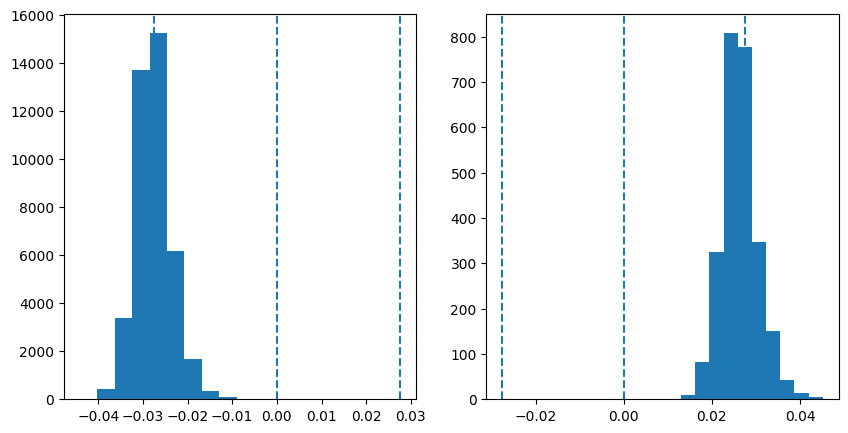

In [24]:
plot_local_fields(HFN, h, ca3)

## Random patterns

### Paper code

In [25]:
import sys
import numpy as np
import torch
import matplotlib.pyplot as pl
import pandas as pd
from scipy.stats import kurtosis, skew
from matplotlib.ticker import FormatStrFormatter
import math
from numpy import trapz
from tqdm import tqdm
from scipy.stats import norm
import matplotlib.ticker as mtick
from matplotlib.ticker import PercentFormatter


def learn_patterns(patterns, sparseness):
    N = patterns.size(dim=1)
    return torch.matmul(patterns-sparseness, patterns.permute(0,2,1)-sparseness)/N

def activation_function(activity,threshold,stochastic,temperature):
    output = activity.clone()
    if(stochastic=='on'):
        temp = torch.rand(output.size()).cuda()
        threshold_stochastic = 0.125*torch.log(temp/(1-temp))*temperature/2
    else:
        threshold_stochastic = torch.zeros(output.size()).cuda()
    output[output-threshold-threshold_stochastic<= 0] = -1
    output[output-threshold-threshold_stochastic > 0] = 1
    return(output)

def network_local_field(state, weights, threshold, sparseness_ratio):
    return torch.matmul(weights,state/2+1/2-sparseness_ratio)-threshold

def network_output(state, weights, threshold, sparseness_ratio, stochastic, temperature):
    return(activation_function(torch.matmul(weights,state/2+1/2-sparseness_ratio) ,threshold, stochastic, temperature))

def patterns_distance(pattern1, pattern2):
    return((1-torch.sum(pattern1*pattern2,1)/pattern1.size(dim=1))/2)

#####
def set_up_the_model(iterations, N, nr_patterns, sparseness_ratio):
    W = torch.zeros((iterations,N,N)).cuda()
    patterns = torch.rand(iterations,N,nr_patterns).cuda()
    patterns[patterns<sparseness_ratio] = 1
    patterns[patterns!=1] = 0
    W = learn_patterns(patterns, sparseness_ratio)
    W = W*(1-torch.eye(N,N).cuda())
    patterns = patterns*2-1
    return patterns, W

def update_network(starting_state, W, threshold, update_steps, sparseness_ratio, stochastic='off', temperature=0):
    # update the network based on the W dynamics
    update_state = starting_state.clone()
    for i in range(update_steps):
        update_state = network_output(update_state, W, threshold, sparseness_ratio, stochastic, temperature)
    return update_state.squeeze()

In [26]:
# GENERAL SETTINGS (see methods)
N = np.array([50, 100, 500, 1000, 5000])
n_sizes = len(N)
update_steps = 1
iterations = 10
batches = 10
sparseness_ratio = 0.06
threshold = (sparseness_ratio**3-sparseness_ratio**2 + sparseness_ratio-2*sparseness_ratio**2+sparseness_ratio**3)/2

In [27]:
N_patterns = 0.1*N

In [28]:
def plot_local_fields(sparseness_ratio, N, threshold, h, patterns):
    m = [-sparseness_ratio**2*(1-sparseness_ratio)*(N-1)/N - threshold, sparseness_ratio*(1-sparseness_ratio)**2*(N-1)/N - threshold]
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    states = patterns.flatten().unique()
    for i, s in enumerate(states):
        axes[i].hist(h[patterns == s].flatten())
        axes[i].axvline(x = m[0], linestyle = '--')
        axes[i].axvline(x = m[1], linestyle = '--')
        axes[i].axvline(x = 0, linestyle = '--')
    fig.suptitle(f'N={N}')
    fig.show()

  0%|          | 0/5 [00:00<?, ?it/s]C:\Users\lucfonta\AppData\Local\Temp\ipykernel_17480\2677991119.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
 40%|████      | 2/5 [00:00<00:00,  4.06it/s]

N=50: FPR=0.0021, FNR=0.2270, kurtosis0=14.5660, kurtosis1=0.5689
N=100: FPR=0.0005, FNR=0.0573, kurtosis0=6.1246, kurtosis1=0.0239


 60%|██████    | 3/5 [00:00<00:00,  3.71it/s]

N=500: FPR=0.0000, FNR=0.0003, kurtosis0=1.0059, kurtosis1=0.1084


 80%|████████  | 4/5 [00:01<00:00,  2.46it/s]

N=1000: FPR=0.0000, FNR=0.0000, kurtosis0=0.4256, kurtosis1=0.0859
N=5000: FPR=0.0000, FNR=0.0000, kurtosis0=0.0815, kurtosis1=0.0567


100%|██████████| 5/5 [00:08<00:00,  1.76s/it]


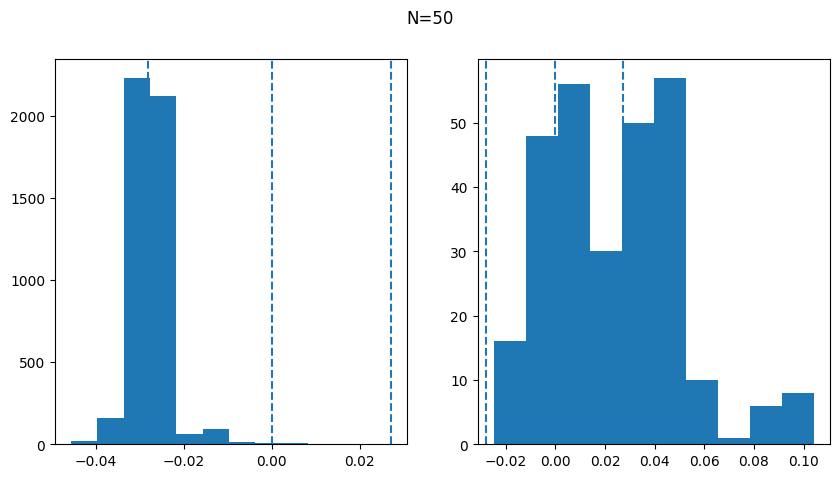

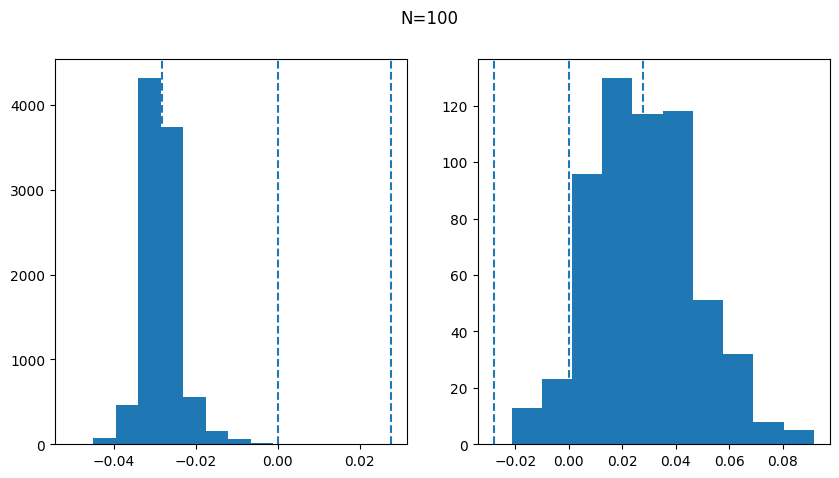

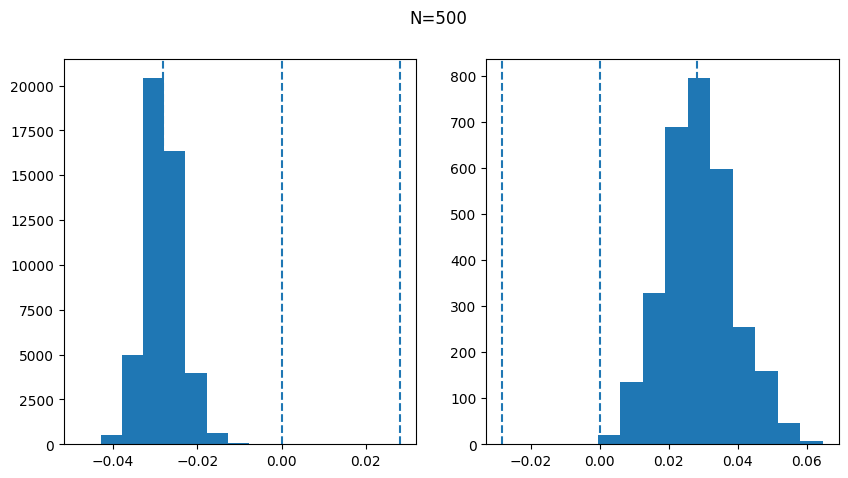

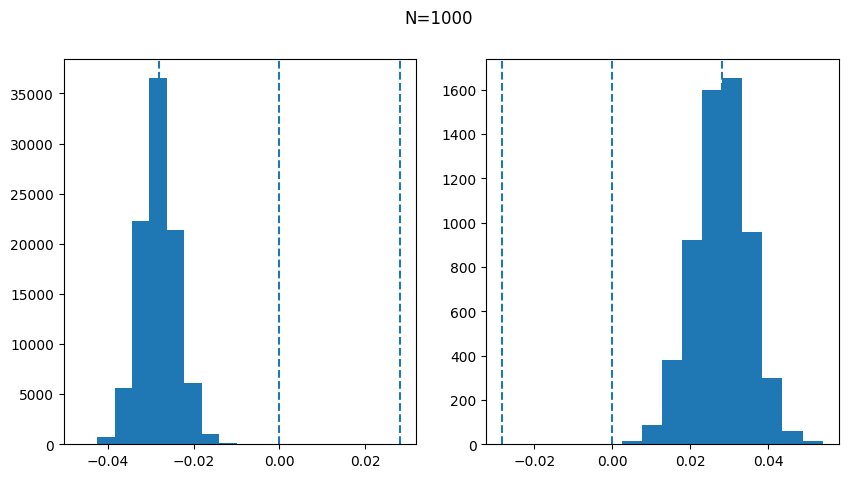

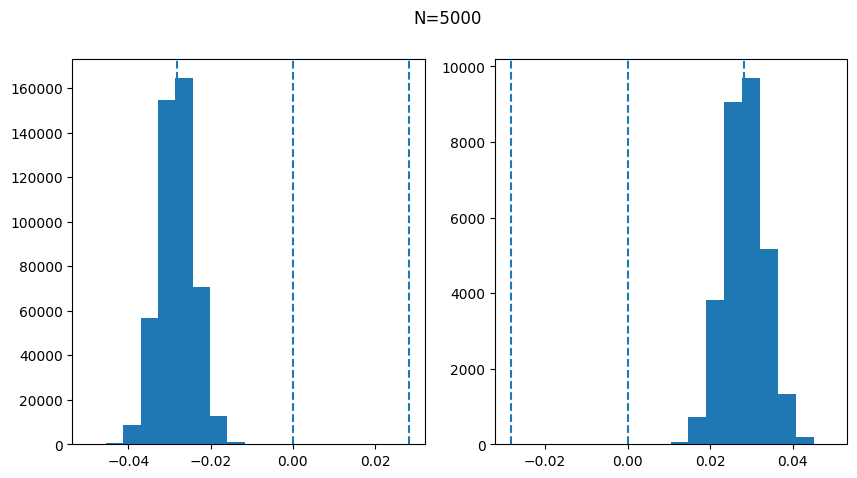

In [29]:
k0 = []
k1 = []
FPR = []
FNR = []

for n in tqdm(range(n_sizes)):
    h = torch.zeros((batches,iterations, N[n])).cuda()
    pattern_batches = torch.zeros((batches, iterations, N[n])).cuda()
    for b in range(batches):        
        patterns, W = set_up_the_model(iterations, N[n], int(N_patterns[n]), sparseness_ratio)
        pattern_batches[b, :, :] = patterns[:,:,0]
        h[b,:,:] = network_local_field(patterns[:,:,0].unsqueeze(-1), W, threshold, sparseness_ratio).squeeze(-1) #only the first pattern
    h = h.cpu()
    pattern_batches = pattern_batches.cpu()
    h0 = h[pattern_batches == -1].flatten()
    h1 = h[pattern_batches == 1].flatten()
    k0.append(kurtosis(h0))
    k1.append(kurtosis(h1))
    FPR.append(sum(h0 > 0)/len(h0))
    FNR.append(sum(h1 < 0)/len(h1))
    print(f"N={N[n]}: FPR={FPR[-1]:.4f}, FNR={FNR[-1]:.4f}, kurtosis0={k0[-1]:.4f}, kurtosis1={k1[-1]:.4f}")
    plot_local_fields(sparseness_ratio, N[n], threshold, h, pattern_batches)

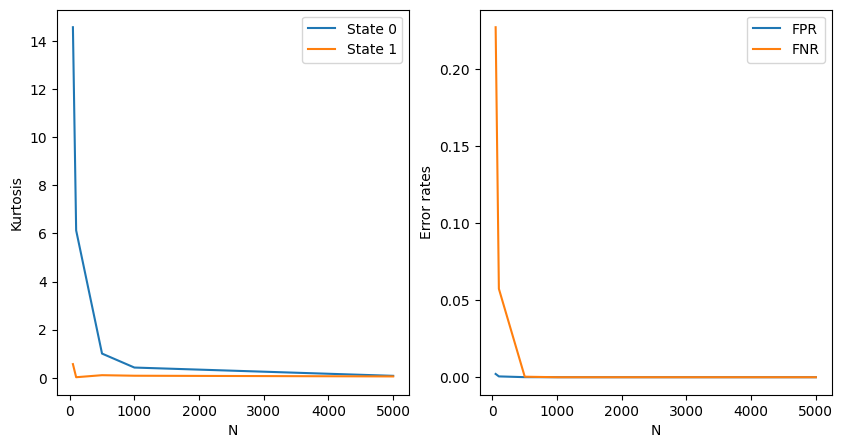

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].plot(N, k0, label='State 0')
axes[0].plot(N, k1, label='State 1')
axes[0].set_ylabel('Kurtosis')
axes[1].plot(N, FPR, label='FPR')
axes[1].plot(N, FNR, label='FNR')
axes[1].set_ylabel('Error rates')
for i in range(2):
    axes[i].set_xlabel('N') 
    axes[i].legend()


### Fix tutorial code

In [31]:
def set_up_the_model(N_neurons, N_patterns, p):
    patterns = np.random.rand(N_neurons, N_patterns)
    patterns[patterns < p] = 1
    patterns[patterns != 1] = 0
    pattern_dict = {str(i+1) : patterns[:, i] for i in range(N_patterns)}
    HFN = SparseHopfieldNetwork(pattern_dict, p=p, transform=False)
    return patterns, pattern_dict, HFN

In [32]:
def network_local_field(state, weights, threshold):
    return weights @ state - threshold

In [33]:
def plot_local_fields(HFN, h, patterns):
    m = [-HFN.p**2*(1-HFN.p)*(HFN.N_neurons-1)/HFN.N_neurons - HFN.theta_opt, HFN.p*(1-HFN.p)**2*(HFN.N_neurons-1)/HFN.N_neurons - HFN.theta_opt]
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    for i in range(2):
        axes[i].hist(h[patterns == i].flatten())
        axes[i].axvline(x = m[0], linestyle = '--')
        axes[i].axvline(x = m[1], linestyle = '--')
        axes[i].axvline(x = 0, linestyle = '--')
    fig.show()

In [34]:
# GENERAL SETTINGS (see methods)
N = np.array([50, 100, 500, 1000, 5000])
N_patterns = (0.1*N).astype(int)
n_sizes = len(N)
update_steps = 1
iterations = 100
sparseness_ratio = 0.06
threshold = (sparseness_ratio**3-sparseness_ratio**2 + sparseness_ratio-2*sparseness_ratio**2+sparseness_ratio**3)/2

  0%|          | 0/5 [00:00<?, ?it/s]C:\Users\lucfonta\.git\static-hpc\src\hpc\models.py:186: RuntimeWarning: invalid value encountered in divide
  return np.dot(self.flattened_patterns, self.state) / (
C:\Users\lucfonta\AppData\Local\Temp\ipykernel_17480\3043392163.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


N=50: FPR=0.0032, FNR=0.1846, kurtosis0=11.8016, kurtosis1=-0.1657
N=100: FPR=0.0004, FNR=0.0722, kurtosis0=7.3653, kurtosis1=0.0791


 60%|██████    | 3/5 [00:00<00:00,  6.38it/s]

N=500: FPR=0.0000, FNR=0.0000, kurtosis0=1.0507, kurtosis1=-0.6907


 80%|████████  | 4/5 [00:02<00:00,  1.61it/s]

N=1000: FPR=0.0000, FNR=0.0000, kurtosis0=0.4660, kurtosis1=0.0526


100%|██████████| 5/5 [00:39<00:00,  7.97s/it]

N=5000: FPR=0.0000, FNR=0.0000, kurtosis0=0.0897, kurtosis1=0.1988


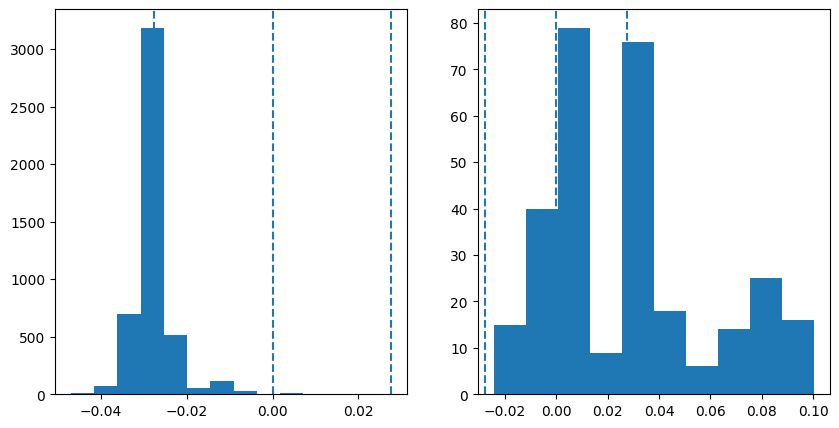

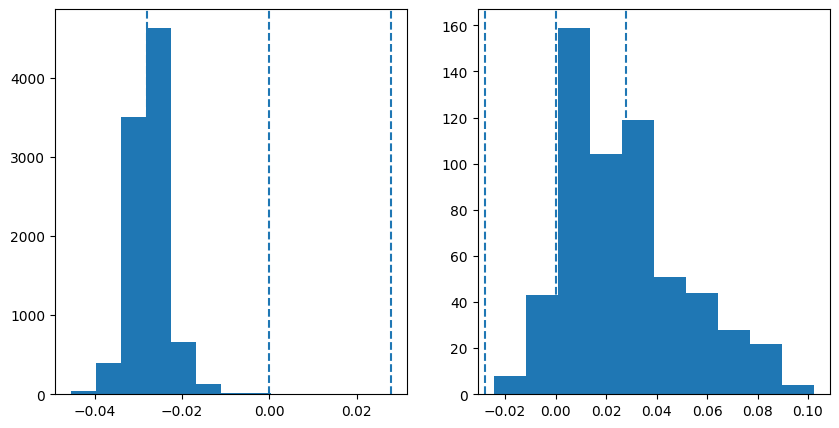

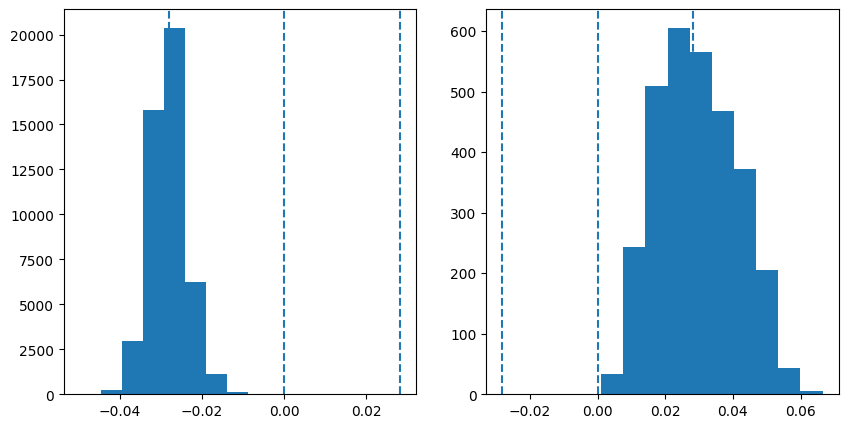

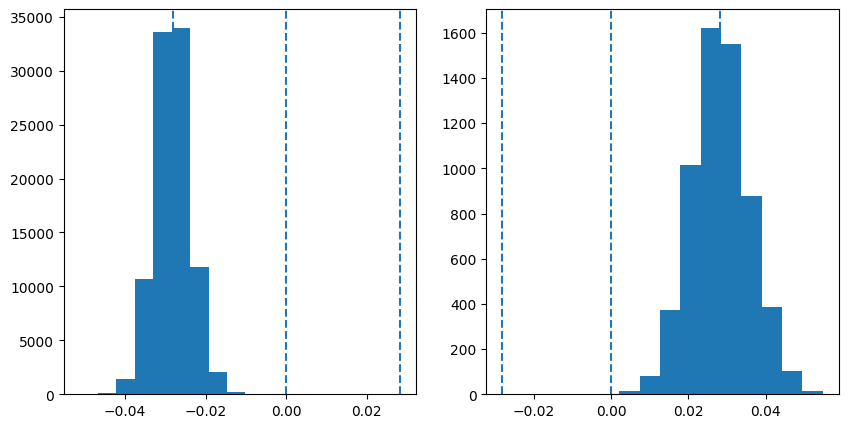

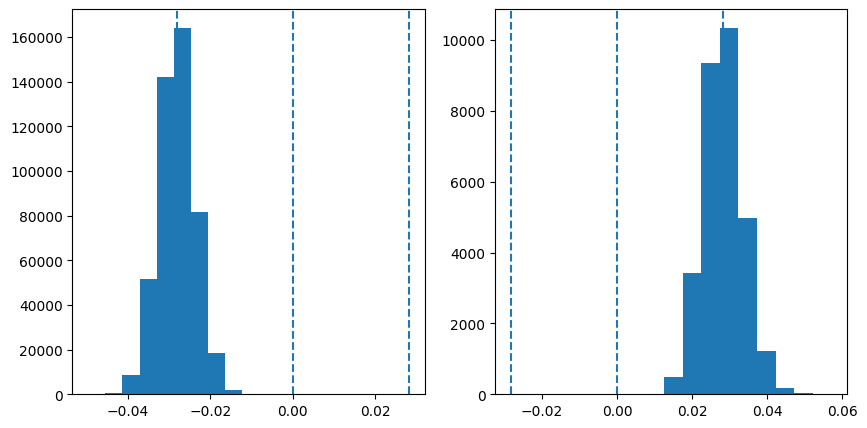

In [35]:
k0 = []
k1 = []
FPR = []
FNR = []

for n in tqdm(range(n_sizes)):
    h = np.zeros((iterations, N[n]))
    pattern_batches = np.zeros((iterations, N[n]))
    for i in range(iterations):        
        patterns, pattern_dict, HFN = set_up_the_model(N[n], N_patterns[n], sparseness_ratio)
        pattern_batches[i, :] = patterns[:, 0]
        h[i,:] = network_local_field(patterns[:,0], HFN.w, HFN.theta) #only the first pattern
    h0 = h[pattern_batches == 0].flatten()
    h1 = h[pattern_batches == 1].flatten()
    k0.append(kurtosis(h0))
    k1.append(kurtosis(h1))
    FPR.append(sum(h0 > 0)/len(h0))
    FNR.append(sum(h1 < 0)/len(h1))
    print(f"N={N[n]}: FPR={FPR[-1]:.4f}, FNR={FNR[-1]:.4f}, kurtosis0={k0[-1]:.4f}, kurtosis1={k1[-1]:.4f}")
    plot_local_fields(HFN, h, pattern_batches) 

In [36]:
HFN.w.shape

(5000, 5000)

# Pattern completion

### Encoding of masked images through MF

In [6]:
alpha=0.9
ca3_half = torch.load(f'./data/recall_cifar10_ca3_alpha={alpha}.pt')

C:\Users\lucfonta\AppData\Local\Temp\ipykernel_20828\2786201834.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ca3_half = torch.load(f'./data/recall_cifar10_ca3_alpha={

Text(0.5, 0.98, 'These are 64 patterns our network will memorize')

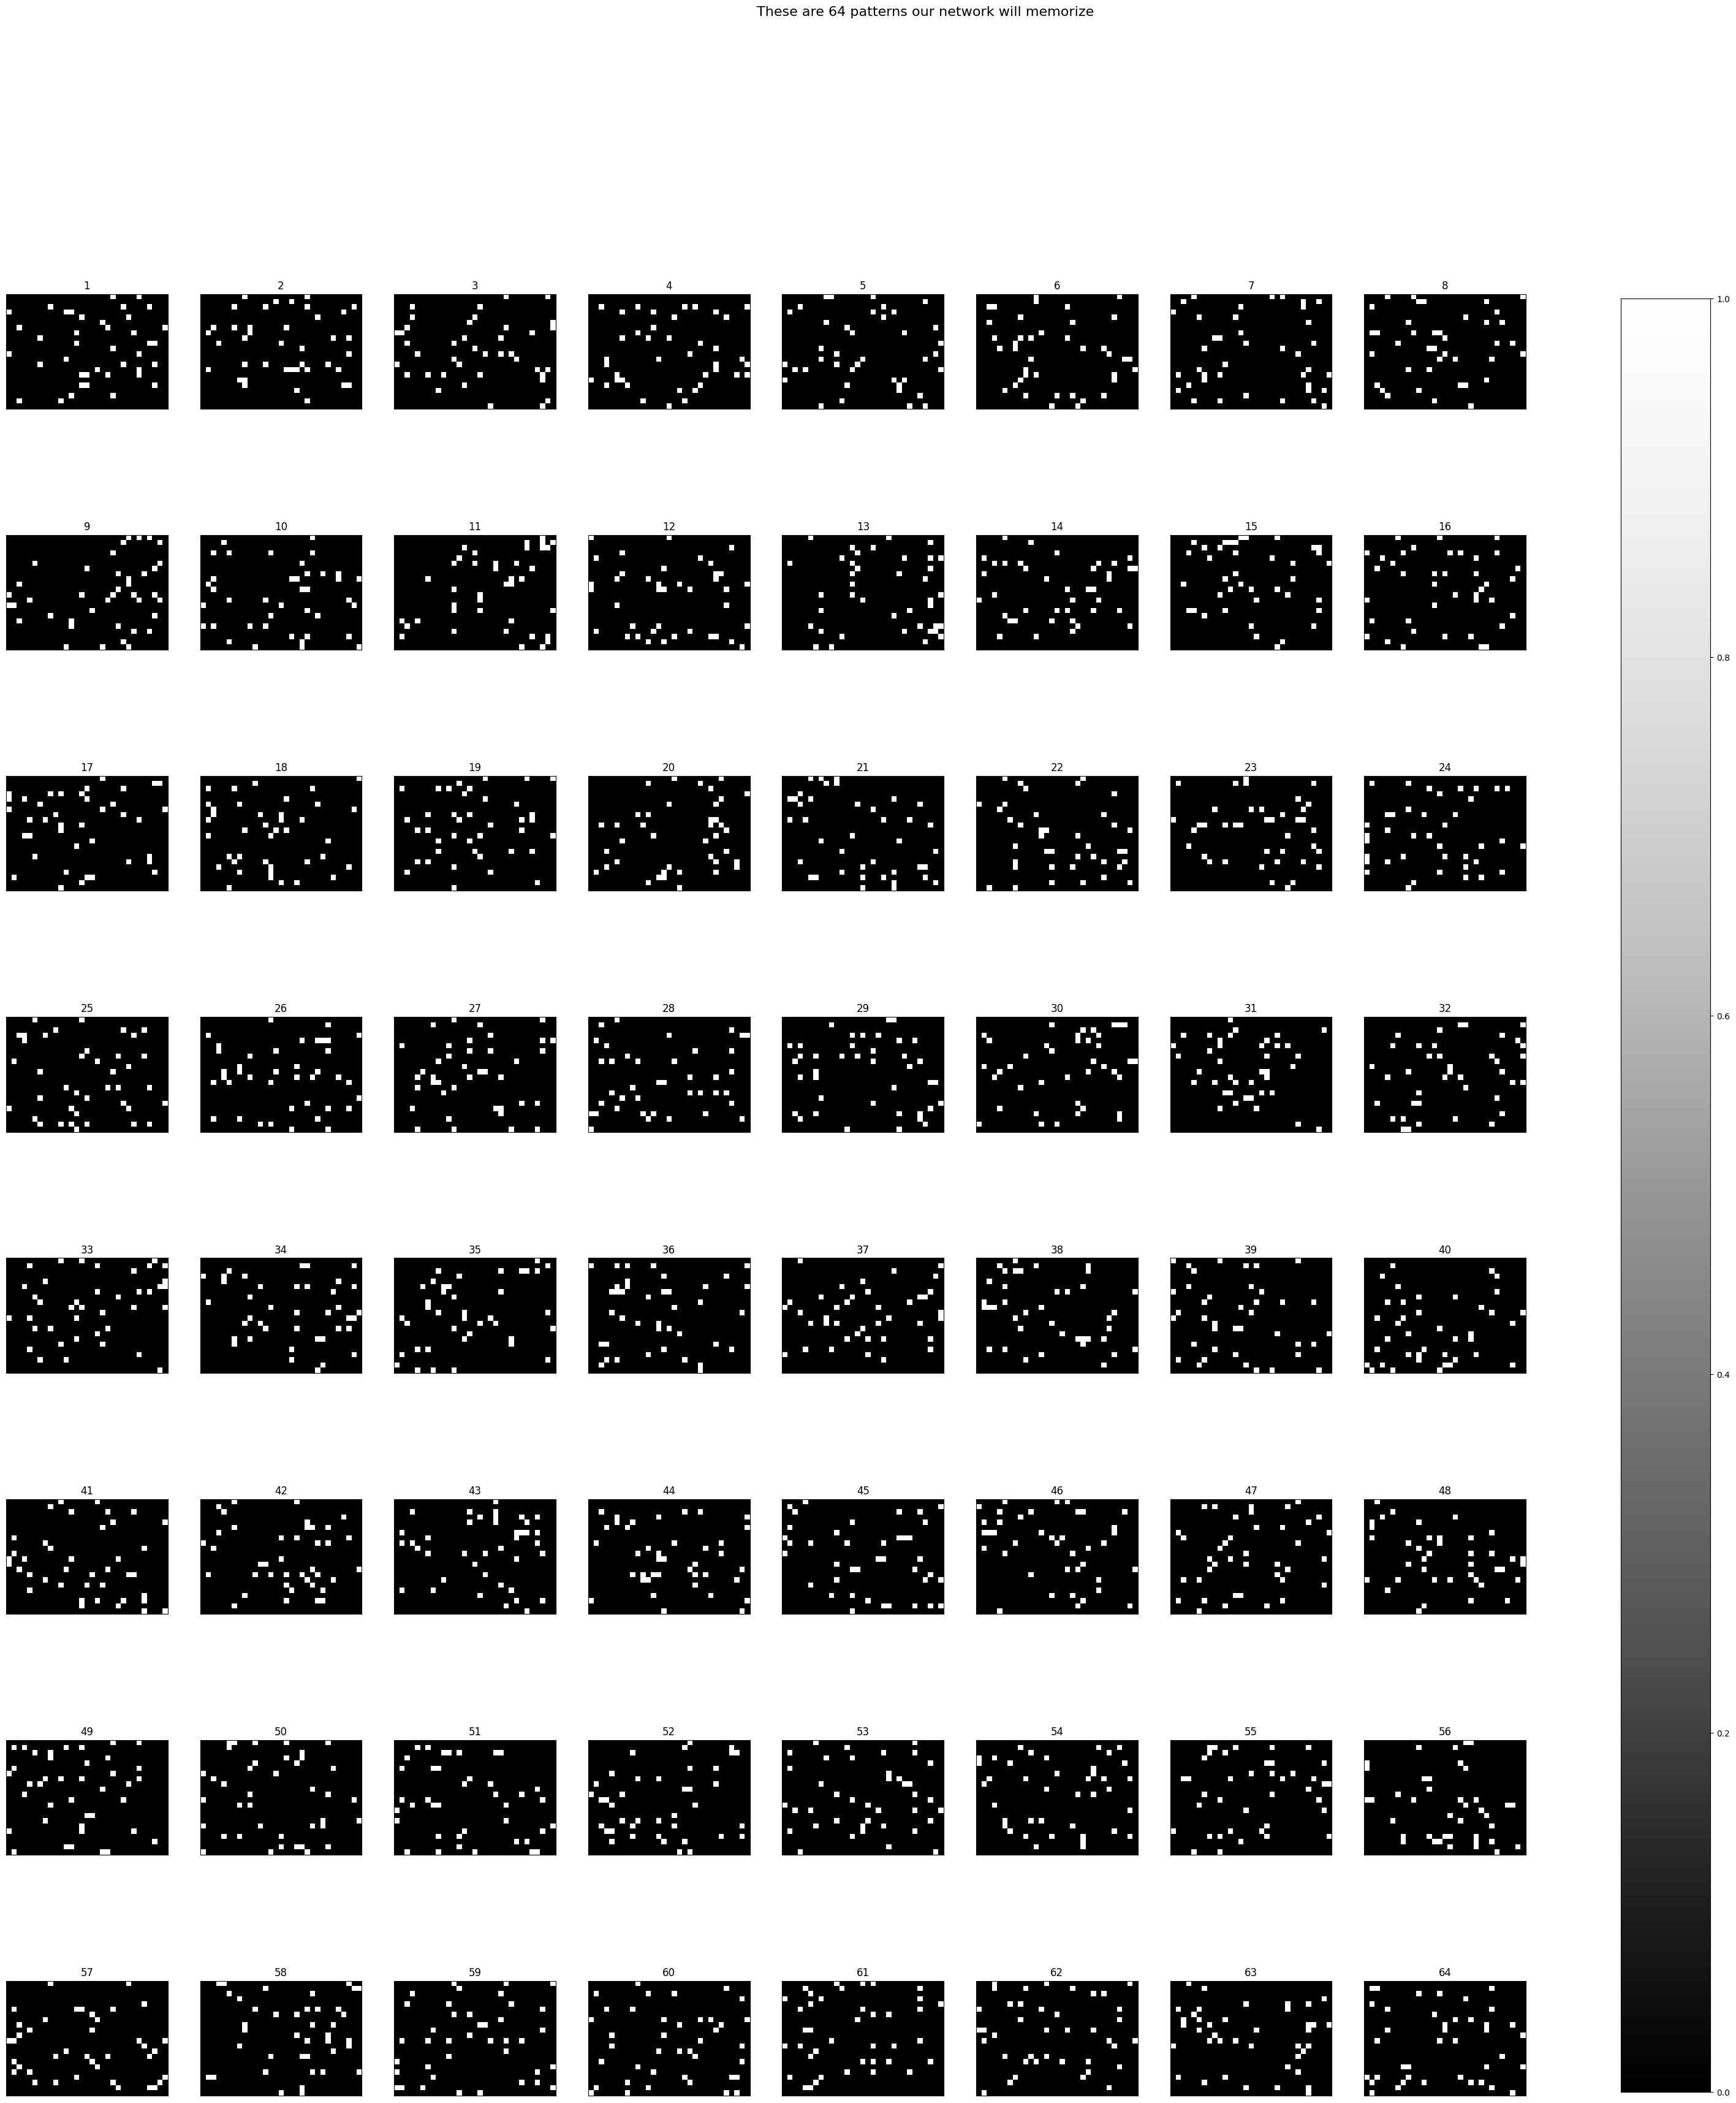

In [7]:
pattern_size = (22, 31)
ca3_half_patterns = {str(i) : ca3_half[i-1].reshape(pattern_size).numpy() for i in range(1,N_patterns+1)}
fig, ax = plot_patterns(ca3_half_patterns)
fig.suptitle(f"These are {ca3_half_patterns.__len__()} patterns our network will memorize", fontsize=16)

In [ ]:
pattern_to_start = '2'

(<Figure size 1600x400 with 2 Axes>,
 array([<Axes: title={'center': 'Initial state'}>,
        <Axes: title={'center': 'Similarity to stored patterns'}>],
       dtype=object))

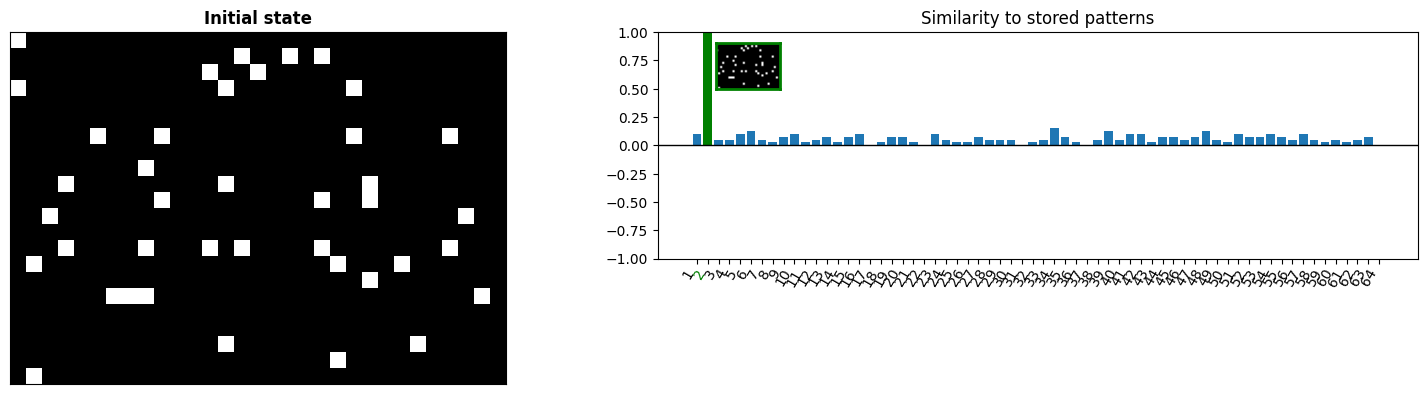

In [ ]:
HFN = SparseHopfieldNetwork(ca3_patterns)
HFN.set_state(ca3_patterns[pattern_to_start].flatten()) 
HFN.visualise(title="Initial state")

(<Figure size 1600x400 with 2 Axes>,
 array([<Axes: title={'center': 'State after 500 updates'}>,
        <Axes: title={'center': 'Similarity to stored patterns'}>],
       dtype=object))

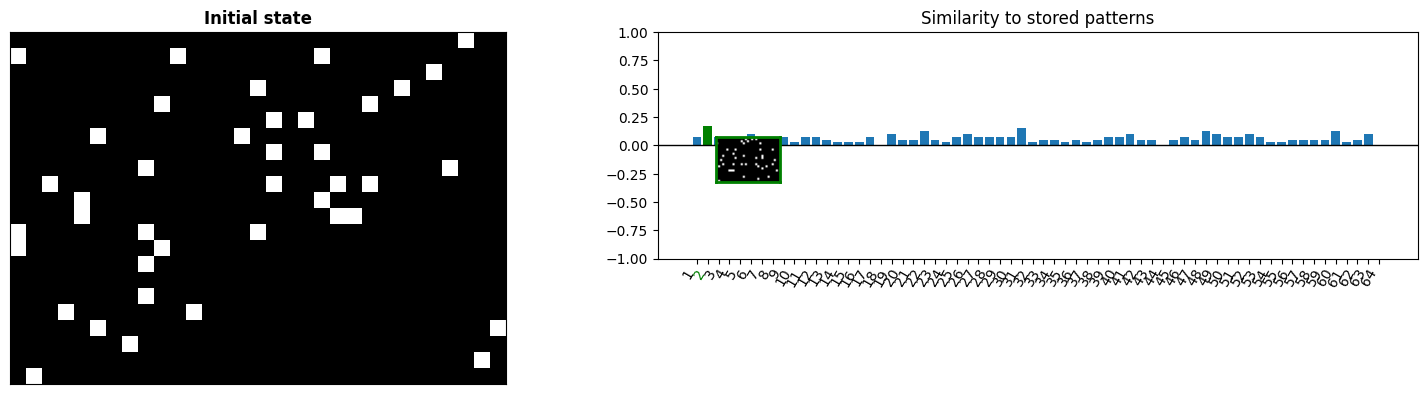

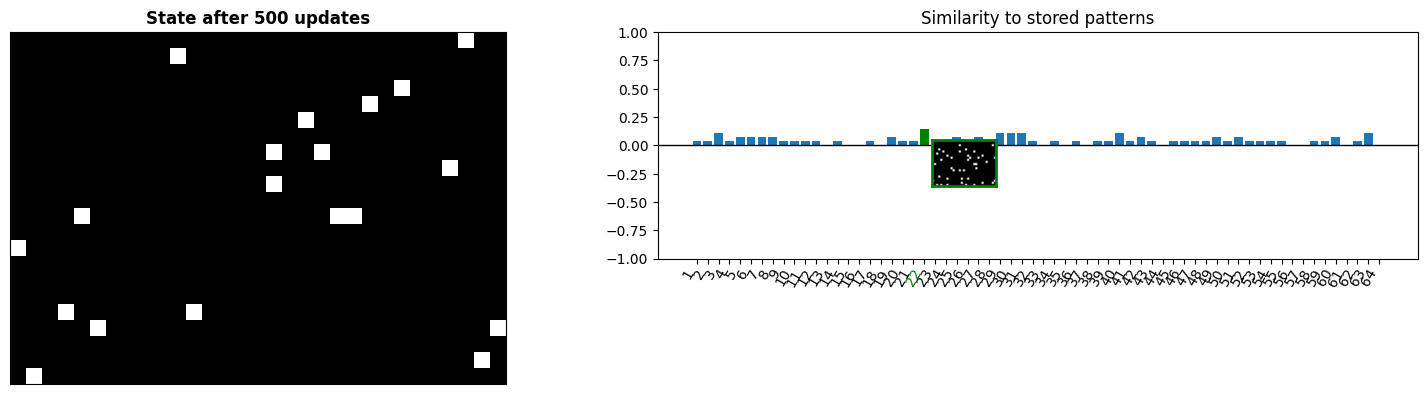

In [17]:
HFN.set_state(ca3_half_patterns[pattern_to_start].flatten()) #reinitialise the state of the network
HFN.visualise(title="Initial state")
for i in range(500):
    HFN.update_state(asynchronous=True)
HFN.visualise(title=f"State after {i+1} updates")

n_steps: 500


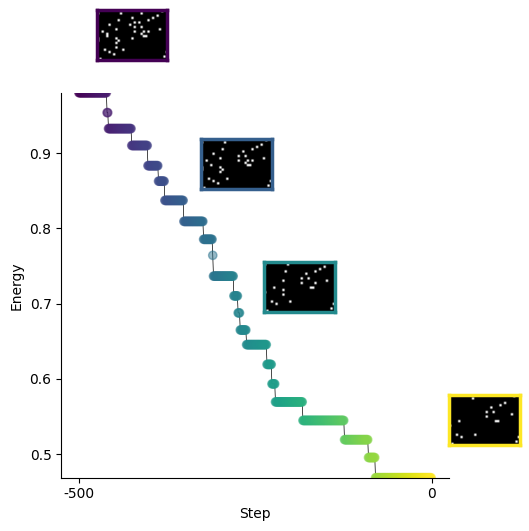

In [18]:
fig, ax = HFN.plot_energy(n_steps=500)

In [22]:
from scipy.spatial import distance
distance = distance.hamming(ca3_half_patterns[pattern_to_start].flatten(), ca3_patterns[pattern_to_start].flatten())
print(distance*ca3.shape[1], int(0.06*ca3.shape[1]))

66.0 40


C:\Users\lucfonta\.git\static-hpc\src\hpc\models.py:186: RuntimeWarning: invalid value encountered in divide
  return np.dot(self.flattened_patterns, self.state) / (


100.0% of the memory patterns are unstable. These are ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64']


C:\Users\lucfonta\.git\static-hpc\src\hpc\models.py:186: RuntimeWarning: invalid value encountered in divide
  return np.dot(self.flattened_patterns, self.state) / (


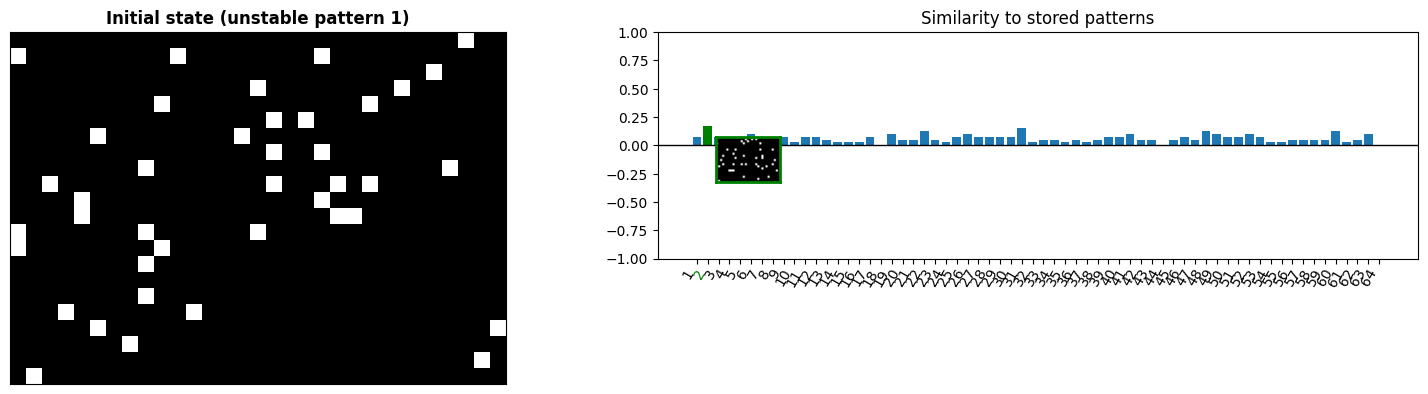

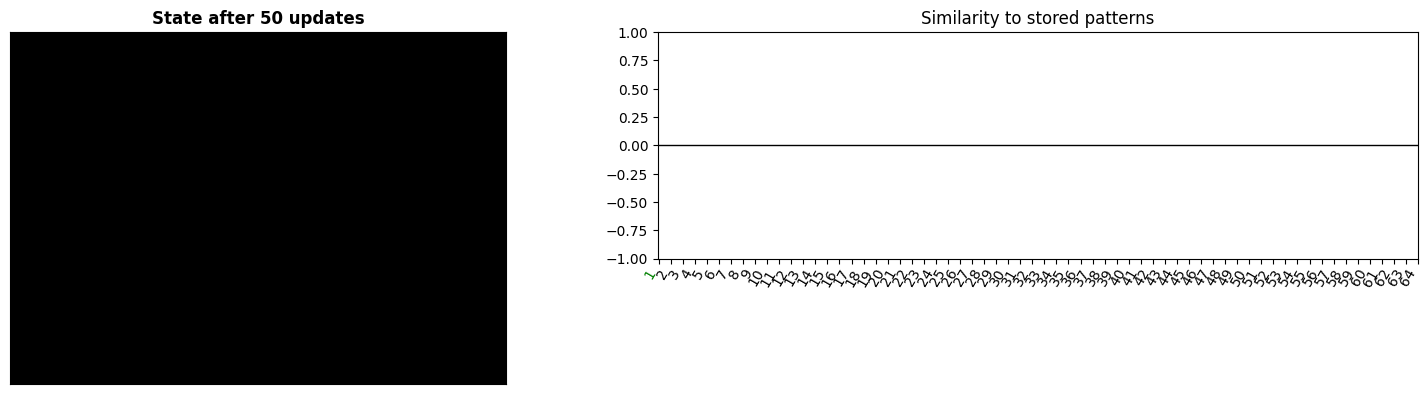

In [ ]:
pcn.utils.seed(0)
# test ALL the memories and set which ones do not converge to the original memories (unstable patterns)
unstable_patterns = []
for pattern in ca3_half_patterns:
    HFN.set_state(ca3_half_patterns[pattern].flatten())
    for i in range(50):
        HFN.update_state(asynchronous=False)
    if not np.all(ca3_patterns[pattern].flatten() == HFN.state): #if a pattern is not stable, add it to the list
        unstable_patterns.append(pattern)

print(f"{100*len(unstable_patterns)/len(ca3_patterns):.1f}% of the memory patterns are unstable. These are {unstable_patterns}")

#visualise an unstable memory
if len(unstable_patterns) > 0:
    HFN.set_state(ca3_half_patterns[unstable_patterns[1]].flatten()) #reinitialise the state of the network
    HFN.visualise(title=f"Initial state (unstable pattern {unstable_patterns[0]})")
    for i in range(50):
        HFN.update_state(asynchronous=False)
    HFN.visualise(title=f"State after {i+1} updates")

### Pertubed CA3

0.0


(<Figure size 1600x400 with 2 Axes>,
 array([<Axes: title={'center': 'State after 50 updates'}>,
        <Axes: title={'center': 'Similarity to stored patterns'}>],
       dtype=object))

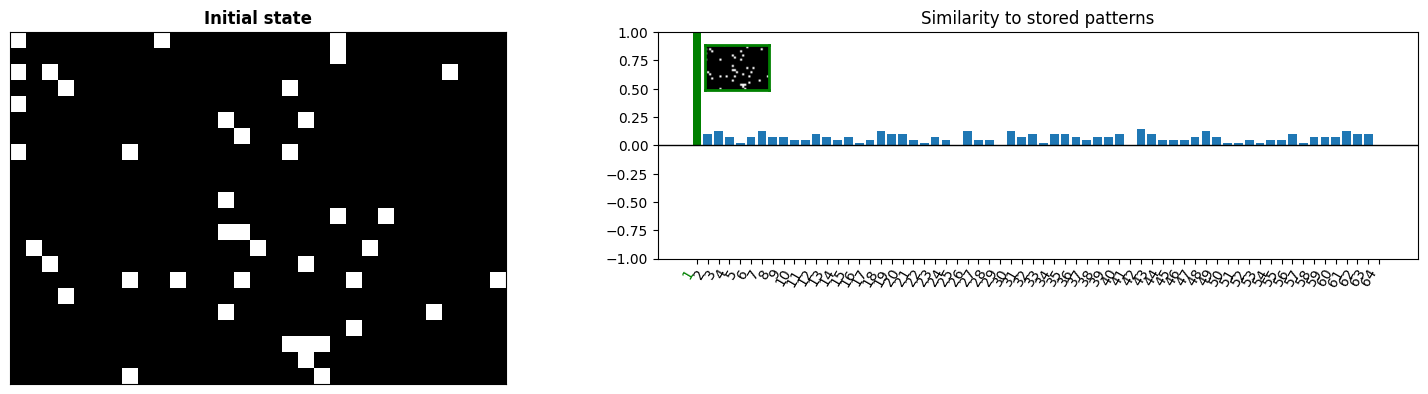

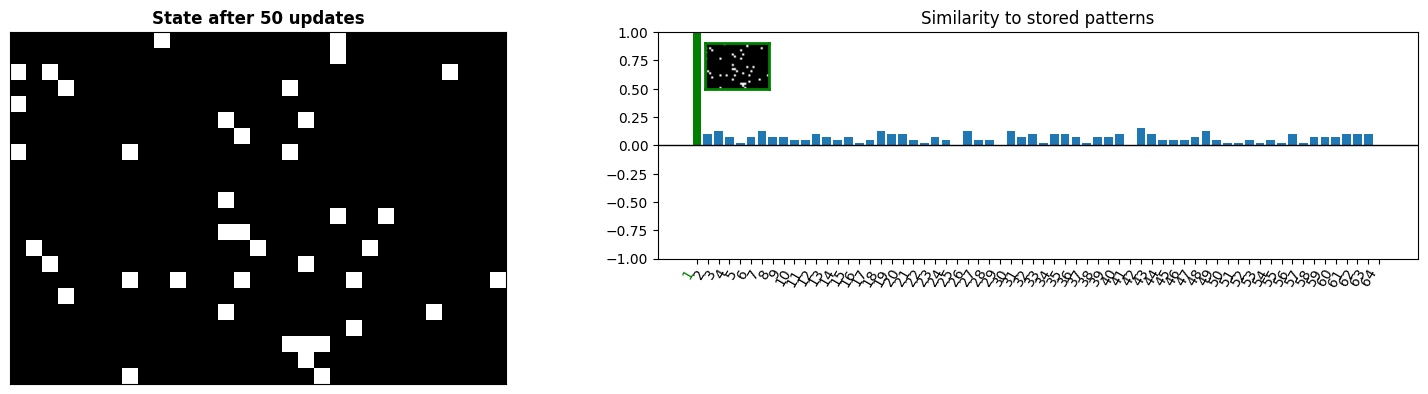

In [16]:
pattern_to_start = '1'
perturbed_pattern = ca3_patterns[pattern_to_start].flatten()
perturbed_pattern[0] = 1
print(ca3_patterns[pattern_to_start].flatten()[0])
HFN.set_state(perturbed_pattern) #reinitialise the state of the network
HFN.visualise(title="Initial state")
for i in range(50):
    HFN.update_state(asynchronous=False)
HFN.visualise(title=f"State after {i+1} updates")

n_steps: 50


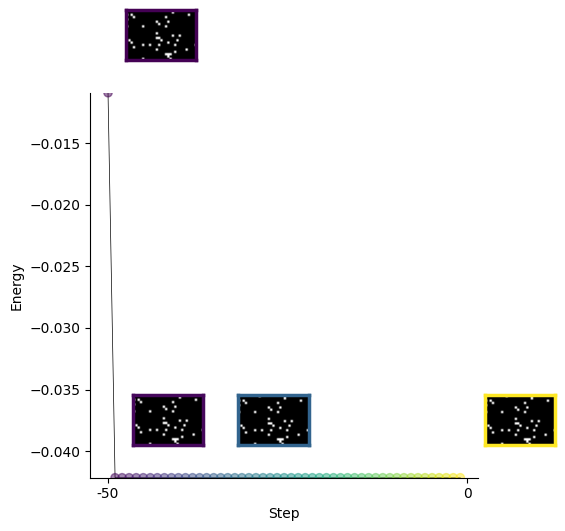

In [21]:
fig, ax = HFN.plot_energy(n_steps=50)

In [22]:
def swap_bits(pattern):
    pattern_flipped = pattern.copy()
    indices0 = np.where(pattern_flipped == 0)[0]
    indices1 = np.where(pattern_flipped == 1)[0]
    i = np.random.randint(len(indices0))
    j = np.random.randint(len(indices1))
    pattern_flipped[indices0[i]] = 1
    pattern_flipped[indices1[j]] = 0
    return pattern_flipped

Flipped 1 bits, Energy: 0.0037194488550427174, Similarity: 0.9750000238418579, Distance:0.002932551319648094
Flipped 2 bits, Energy: 0.05253640363612733, Similarity: 0.949999988079071, Distance:0.005865102639296188
Flipped 3 bits, Energy: 0.1050612370555738, Similarity: 0.925000011920929, Distance:0.008797653958944282
Flipped 4 bits, Energy: 0.15595109614124103, Similarity: 0.8999999761581421, Distance:0.011730205278592375
Flipped 5 bits, Energy: 0.1989029518655746, Similarity: 0.875, Distance:0.01466275659824047
Flipped 6 bits, Energy: 0.24220028256178017, Similarity: 0.8500000238418579, Distance:0.017595307917888565
Flipped 7 bits, Energy: 0.280407833461497, Similarity: 0.824999988079071, Distance:0.020527859237536656
Flipped 8 bits, Energy: 0.3233596860226986, Similarity: 0.800000011920929, Distance:0.02346041055718475
Flipped 9 bits, Energy: 0.3669181556702773, Similarity: 0.7749999761581421, Distance:0.026392961876832845
Flipped 10 bits, Energy: 0.4138389930029057, Similarity: 0.7

C:\Users\lucfonta\.git\static-hpc\src\hpc\models.py:185: RuntimeWarning: invalid value encountered in divide
  return np.dot(self.flattened_patterns, self.state) / (


n_steps: 50


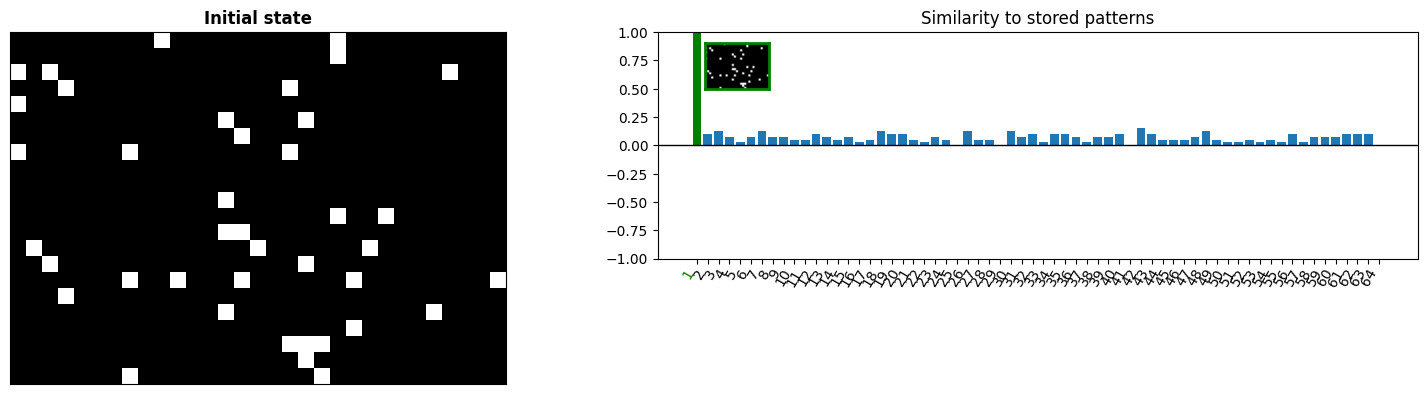

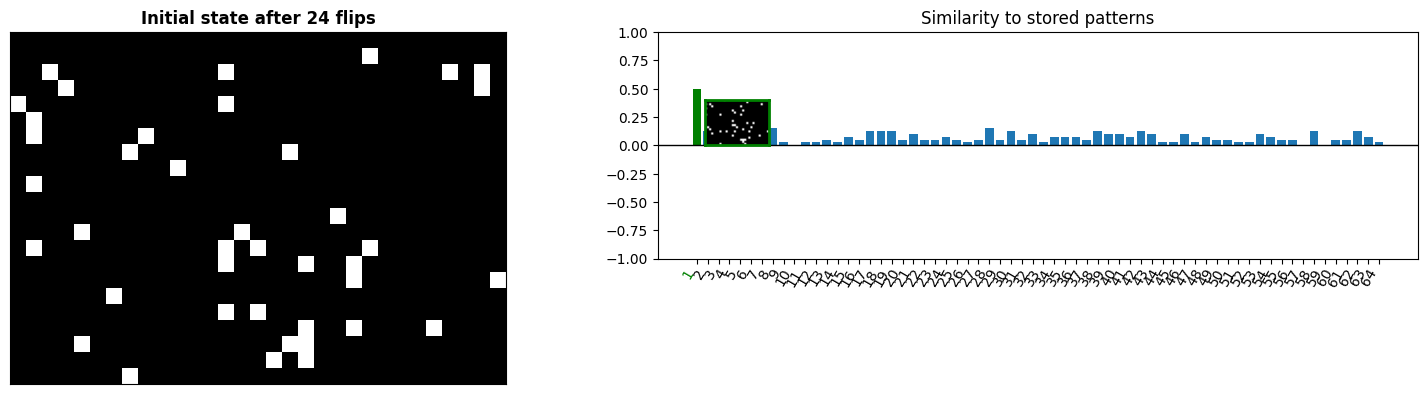

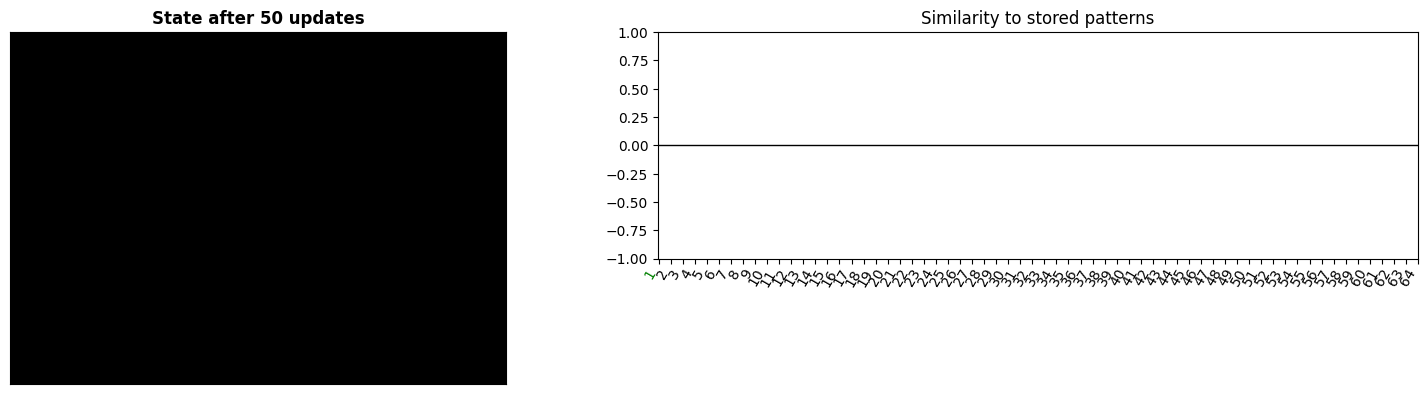

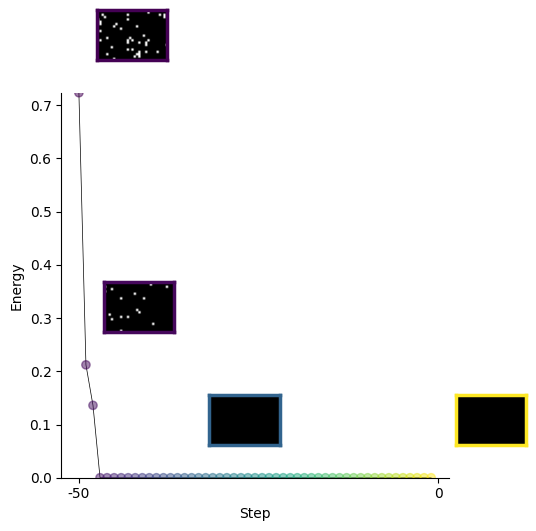

In [23]:
pcn.utils.seed(0)
pattern_to_start ='1'
pattern = ca3_patterns[pattern_to_start].flatten()
HFN.set_state(pattern) 
HFN.visualise(title="Initial state")
E = [HFN.get_energy()]
S = [HFN.get_similarities()[int(pattern_to_start)-1]]
D = [0]
for i in range(HFN.N_neurons):
    pattern = swap_bits(pattern)
    HFN.set_state(pattern)
    E.append(HFN.get_energy())
    S.append(HFN.get_similarities()[int(pattern_to_start)-1])
    D.append(distance.hamming(pattern, ca3_patterns[pattern_to_start].flatten()))
    print(f"Flipped {i+1} bits, Energy: {E[-1]}, Similarity: {S[-1]}, Distance:{D[-1]}")
    for j in range(50):
        HFN.update_state(asynchronous=False)
    if not np.all(ca3_patterns[pattern_to_start].flatten() == HFN.state): #if a pattern is not stable, add it to the list
        print(f"Pattern did not converge after swapping {i+1} bits")
        HFN.visualise(steps_back=j+1, title=f"Initial state after {i+1} flips")
        HFN.visualise(title=f"State after {j+1} updates")
        fig, ax = HFN.plot_energy(n_steps=50)
        break


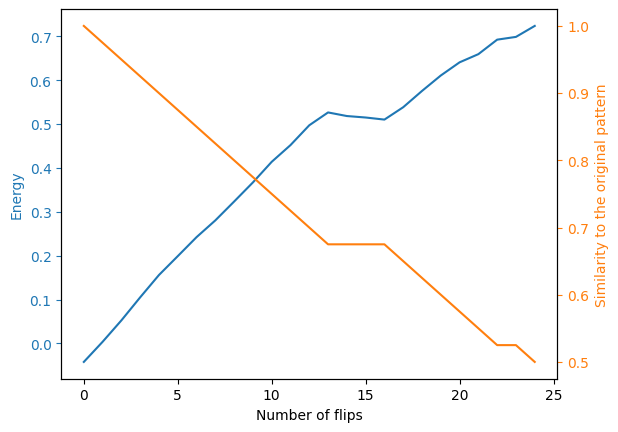

In [24]:
import seaborn as sns
palette = sns.color_palette()
fig, ax1 = plt.subplots()
ax1.plot(E, color=palette[0])
ax2 = ax1.twinx()
ax2.plot(S, color=palette[1])
ax1.set_xlabel('Number of flips')
ax1.set_ylabel('Energy', color=palette[0])
ax1.tick_params('y', colors=palette[0])
ax2.set_ylabel('Similarity to the original pattern', color=palette[1])
ax2.tick_params('y', colors=palette[1])

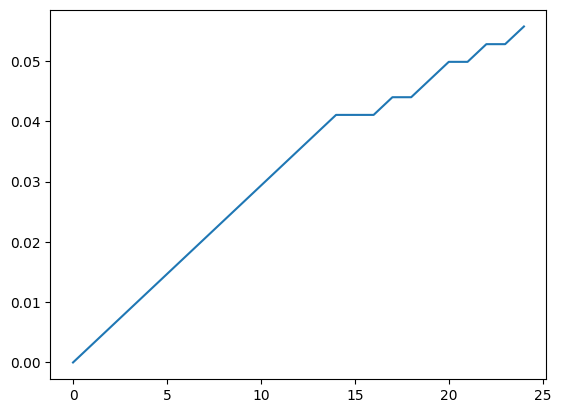

In [27]:
plt.plot(D)

### PP-CA3 patterns

In [2]:
alpha = 0.9
cifar10_patterns_half = torch.load(f'data/recall_cifar10_patterns_alpha={alpha}.pt')
ca3_half = cifar10_patterns_half['ca3']

C:\Users\lucfonta\AppData\Local\Temp\ipykernel_53424\1073616262.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cifar10_patterns_half = torch.load(f'data/recall_cifar10_

Text(0.5, 0.98, 'These are 64 patterns our network will memorize')

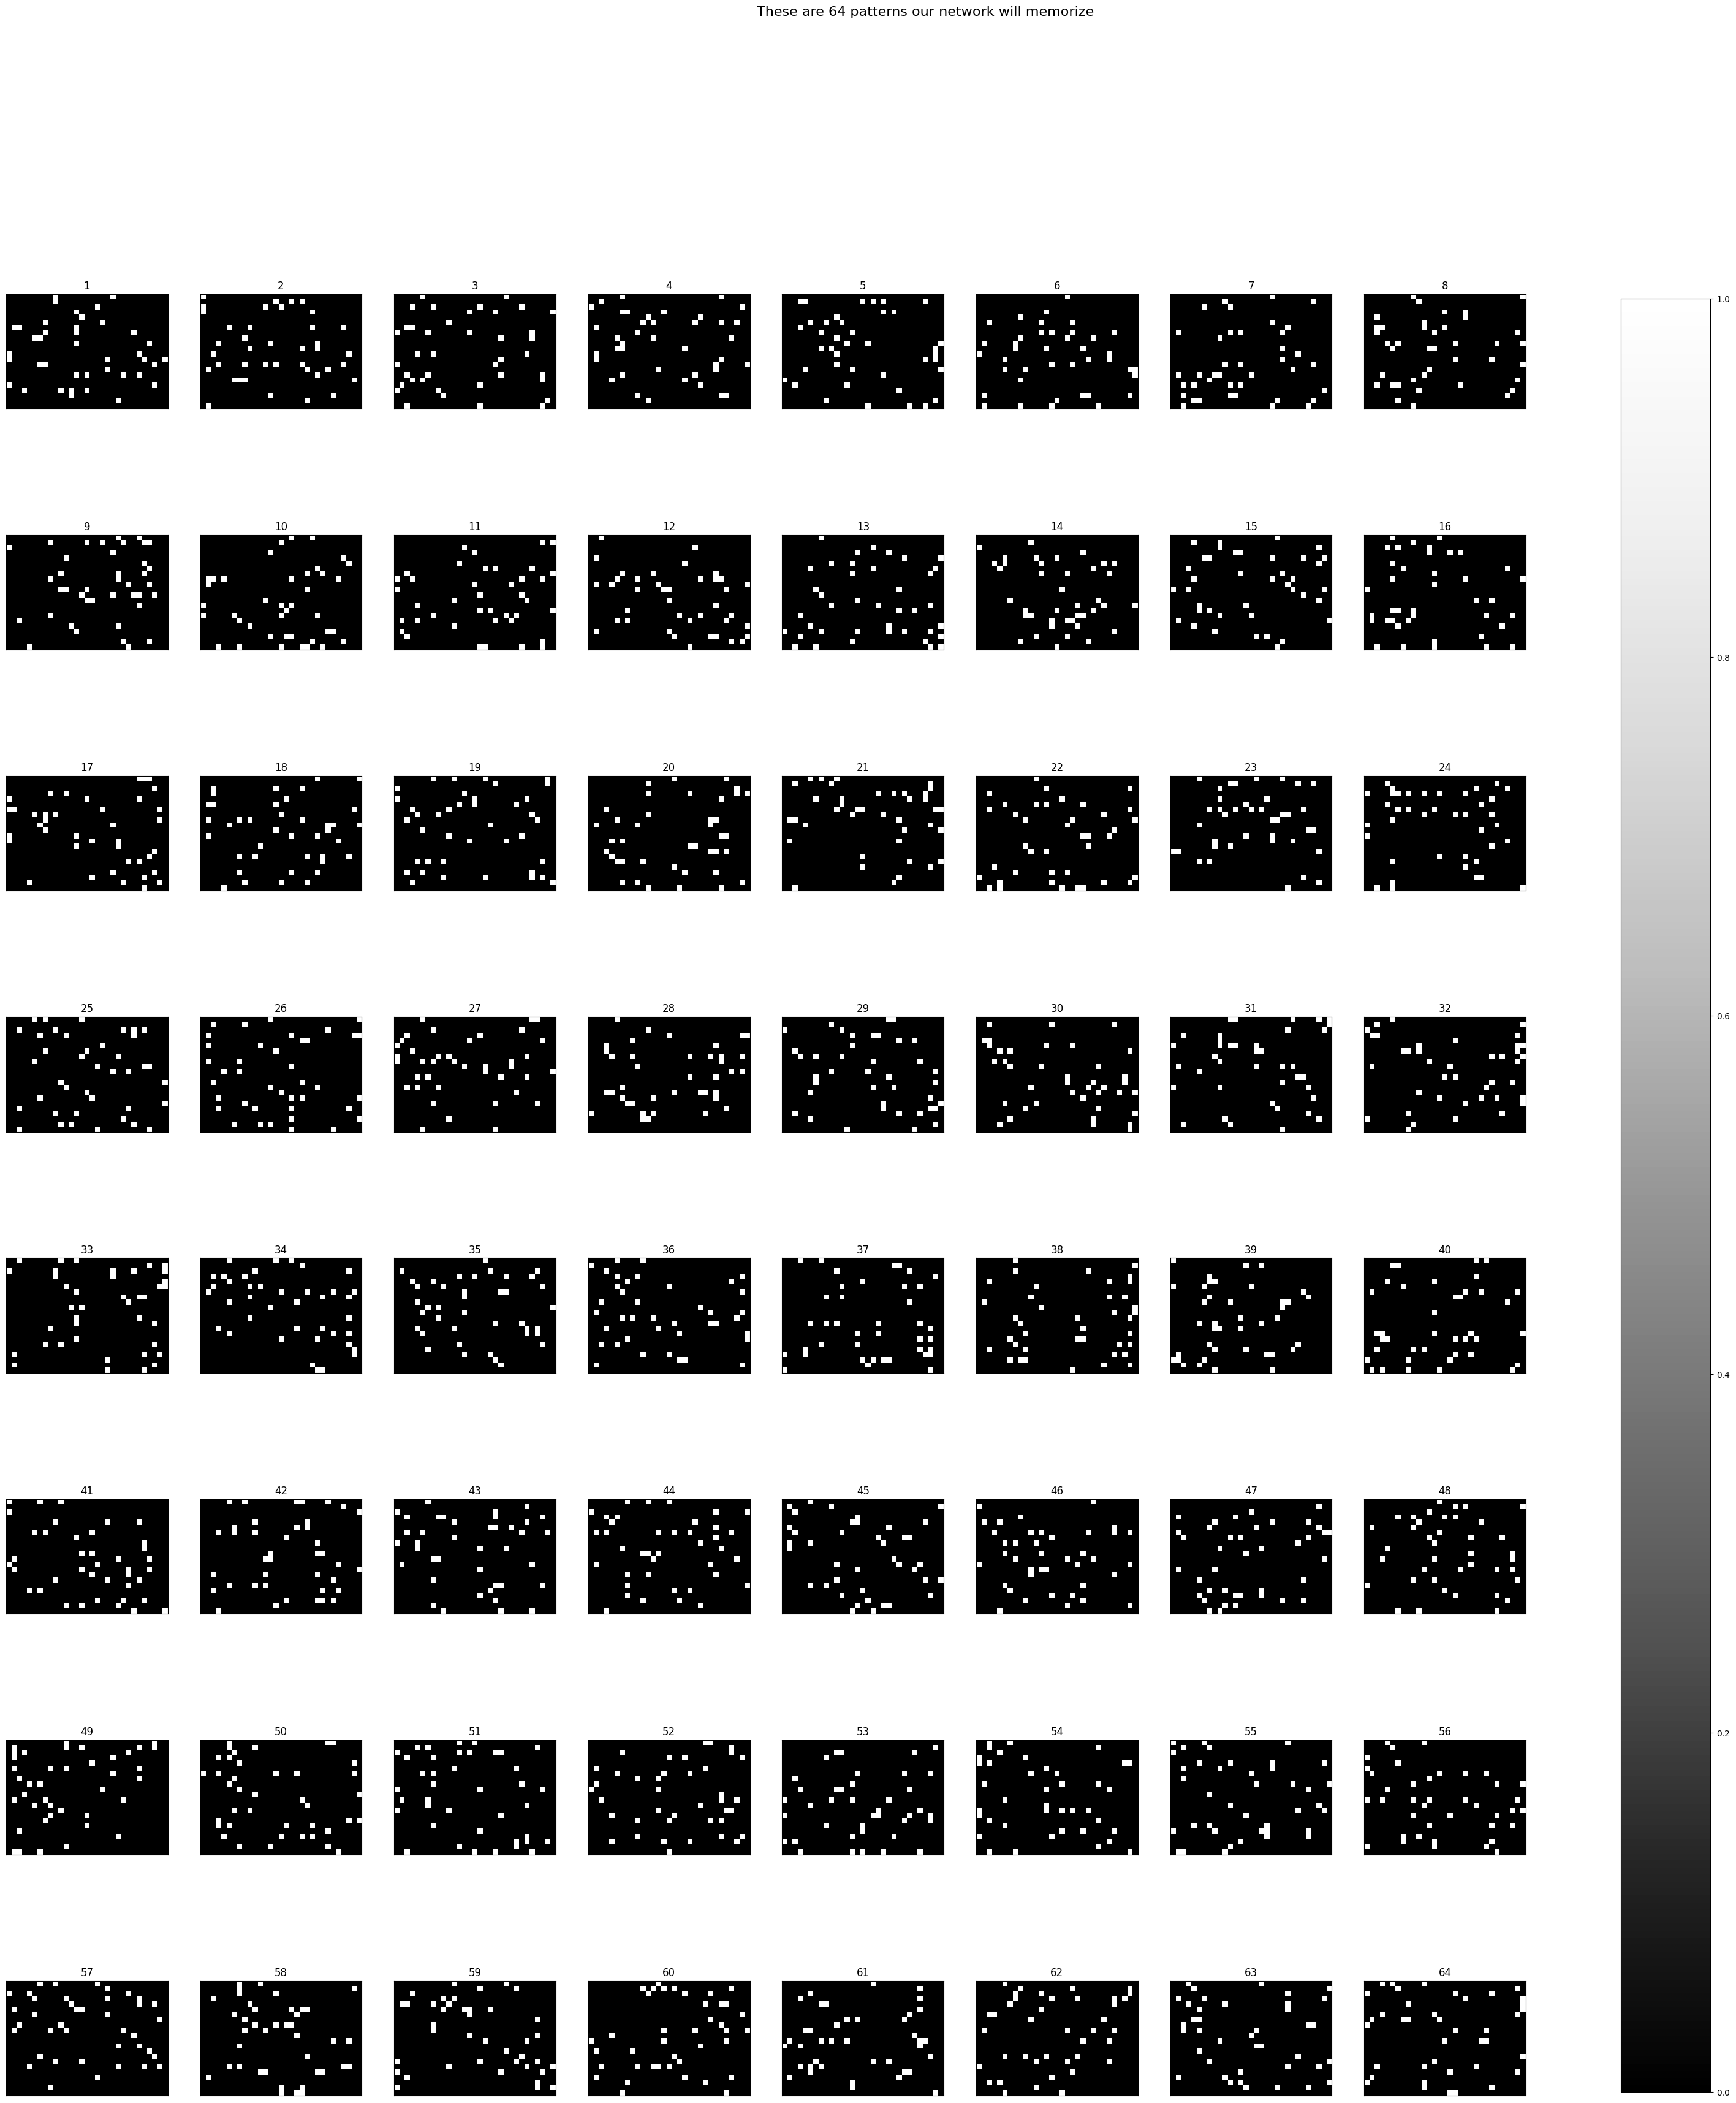

In [3]:
pattern_size = (22, 31)
N_patterns = len(ca3_half)
ca3_half_patterns = {str(i) : ca3_half[i-1].reshape(pattern_size).numpy() for i in range(1,N_patterns+1)}
fig, ax = plot_patterns(ca3_half_patterns)
fig.suptitle(f"These are {ca3_half_patterns.__len__()} patterns our network will memorize", fontsize=16)

(<Figure size 1600x400 with 2 Axes>,
 array([<Axes: title={'center': 'Initial state'}>,
        <Axes: title={'center': 'Similarity to stored patterns'}>],
       dtype=object))

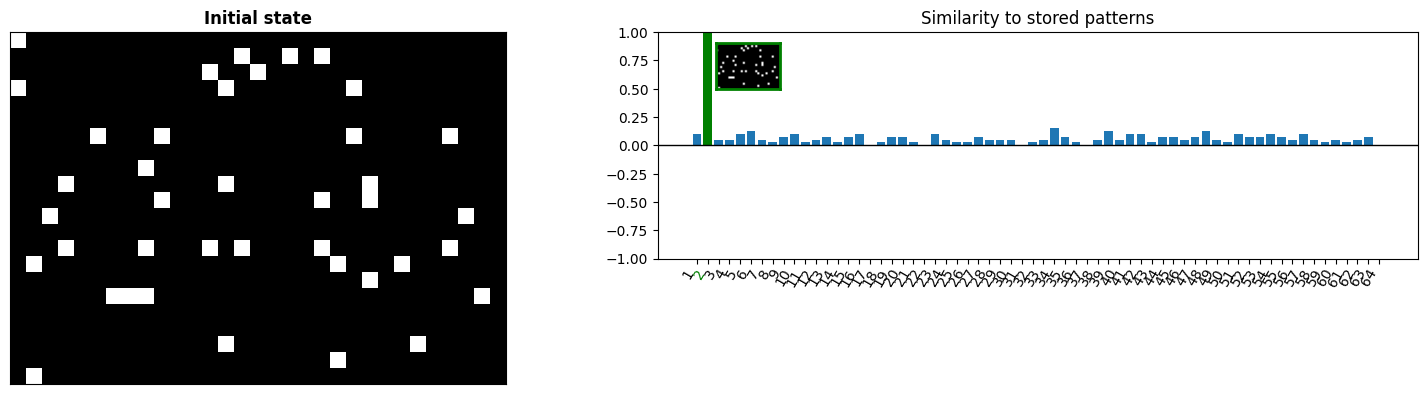

In [8]:
pattern_to_start = '2'
HFN = SparseHopfieldNetwork(ca3_patterns)
HFN.set_state(ca3_patterns[pattern_to_start].flatten()) 
HFN.visualise(title="Initial state")

(<Figure size 1600x400 with 2 Axes>,
 array([<Axes: title={'center': 'State after 500 updates'}>,
        <Axes: title={'center': 'Similarity to stored patterns'}>],
       dtype=object))

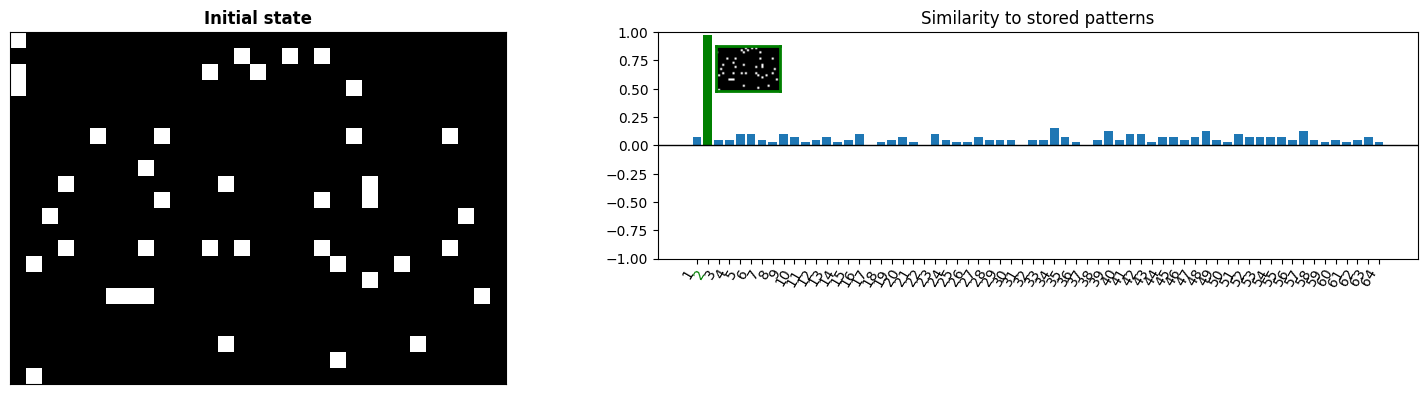

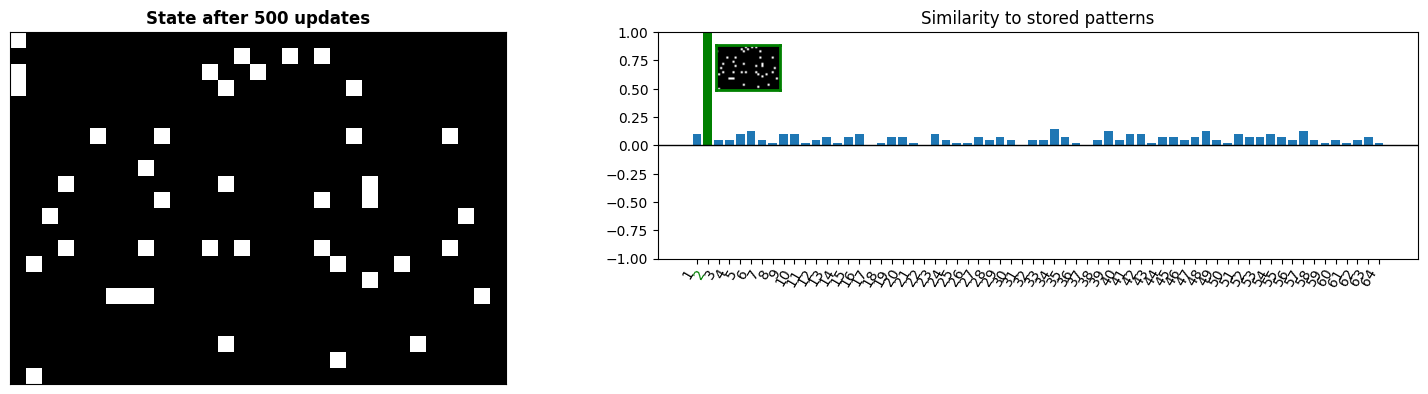

In [9]:
HFN.set_state(ca3_half_patterns[pattern_to_start].flatten()) #reinitialise the state of the network
HFN.visualise(title="Initial state")
for i in range(500):
    HFN.update_state(asynchronous=True)
HFN.visualise(title=f"State after {i+1} updates")

n_steps: 500


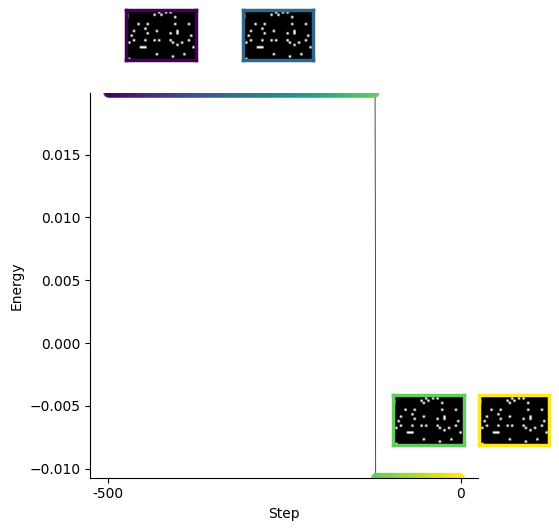

In [10]:
fig, ax = HFN.plot_energy(n_steps=500)

In [11]:
pcn.utils.seed(0)
# test ALL the memories and set which ones do not converge to the original memories (unstable patterns)
unstable_patterns = []
for pattern in ca3_half_patterns:
    HFN.set_state(ca3_half_patterns[pattern].flatten())
    for i in range(50):
        HFN.update_state(asynchronous=False)
    if not np.all(ca3_patterns[pattern].flatten() == HFN.state): #if a pattern is not stable, add it to the list
        unstable_patterns.append(pattern)

print(f"{100*len(unstable_patterns)/len(ca3_patterns):.1f}% of the memory patterns are unstable. These are {unstable_patterns}")

#visualise an unstable memory
if len(unstable_patterns) > 0:
    HFN.set_state(ca3_half_patterns[unstable_patterns[1]].flatten()) #reinitialise the state of the network
    HFN.visualise(title=f"Initial state (unstable pattern {unstable_patterns[0]})")
    for i in range(50):
        HFN.update_state(asynchronous=False)
    HFN.visualise(title=f"State after {i+1} updates")

0.0% of the memory patterns are unstable. These are []
